In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import skew, kurtosis
from sklearn.preprocessing import StandardScaler, PowerTransformer
from sklearn.decomposition import PCA
from statsmodels.stats.outliers_influence import variance_inflation_factor

pd.set_option("display.max_columns", 200)
sns.set_theme(style="whitegrid")

In [2]:
master = pd.read_parquet("data_processed/f1_feature_store_master.parquet")
prerace = pd.read_parquet("data_processed/f1_feature_store_prerace.parquet")
strategy = pd.read_parquet("data_processed/f1_feature_store_strategy.parquet")

In [3]:
print("Master:", master.shape)
print("Pre-race:", prerace.shape)
print("Strategy:", strategy.shape)

Master: (26759, 103)
Pre-race: (26759, 49)
Strategy: (26759, 67)


In [4]:
master.head()

,resultId,raceId,driverId,constructorId,number_x,grid,position,positionText,positionOrder,points,laps,time_x,milliseconds,fastestLap,rank,fastestLapTime,fastestLapSpeed,statusId,year,round,circuitId,name_x,date,time_y,fp1_date,fp1_time,fp2_date,fp2_time,fp3_date,fp3_time,quali_date,quali_time,sprint_date,sprint_time,driverRef,number_y,code,forename,surname,dob,nationality_x,constructorRef,name_y,nationality_y,circuitRef,name,location,country,lat,lng,alt,status,temp_avg,temp_max,temp_min,precipitation,wind_speed,humidity_avg,month,abs_lat,temp_range,is_wet_race,high_altitude_track,qualifying_position,best_qualifying_time_ms,made_q2,made_q3,sprint_grid,sprint_position_order,sprint_points,sprint_laps,sprint_milliseconds,sprint_status_id,pit_stop_count,avg_pit_stop_ms,min_pit_stop_ms,max_pit_stop_ms,total_pit_stop_ms,first_pit_lap,last_pit_lap,lap_count_recorded,avg_lap_time_ms,median_lap_time_ms,std_lap_time_ms,fastest_lap_in_race_ms,slowest_lap_ms,target_points,finish_position,grid_clean,is_dnf,driver_avg_finish_last5,driver_points_last5,driver_dnf_rate_last5,driver_avg_grid_last5,constructor_points_last5,constructor_dnf_rate_last5,constructor_avg_finish_last5,driver_standing_points_prerace,driver_standing_position_prerace,driver_standing_wins_prerace,constructor_standing_points_prerace,constructor_standing_position_prerace,constructor_standing_wins_prerace
0,1,18,1,1,22,1,1,1,1,10.0,58,1:34:50.616,5690616.0,39,2,1:27.452,218.300,1,2008,1,1,Australian Grand Prix,2008-03-16,04:30:00,\N,\N,\N,\N,\N,\N,\N,\N,\N,\N,hamilton,44,HAM,Lewis,Hamilton,1985-01-07,British,mclaren,McLaren,British,albert_park,Albert Park Grand Prix Circuit,Melbourne,Australia,-37.8497,144.968,10,Finished,27.9,38.4,18.1,0.0,23.1,41.0,3,37.8497,20.3,0,0,1.0,NaN,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,58.0,98114.068966,88665.5,20990.356845,87452.0,166432.0,1,1,1.0,0,6.6,25.0,0.2,2.0,16.0,0.4,10.4,109.0,2.0,4.0,218.0,11.0,8.0
1,2,18,2,2,3,5,2,2,2,8.0,58,+5.478,5696094.0,41,3,1:27.739,217.586,1,2008,1,1,Australian Grand Prix,2008-03-16,04:30:00,\N,\N,\N,\N,\N,\N,\N,\N,\N,\N,heidfeld,\N,HEI,Nick,Heidfeld,1977-05-10,German,bmw_sauber,BMW Sauber,German,albert_park,Albert Park Grand Prix Circuit,Melbourne,Australia,-37.8497,144.968,10,Finished,27.9,38.4,18.1,0.0,23.1,41.0,3,37.8497,20.3,0,0,5.0,NaN,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,58.0,98208.517241,89388.0,20212.298423,87739.0,166678.0,1,2,5.0,0,7.2,14.0,0.2,5.8,9.0,0.4,10.0,61.0,5.0,0.0,101.0,2.0,0.0
2,3,18,3,3,7,7,3,3,3,6.0,58,+8.163,5698779.0,41,5,1:28.090,216.719,1,2008,1,1,Australian Grand Prix,2008-03-16,04:30:00,\N,\N,\N,\N,\N,\N,\N,\N,\N,\N,rosberg,6,ROS,Nico,Rosberg,1985-06-27,German,williams,Williams,British,albert_park,Albert Park Grand Prix Circuit,Melbourne,Australia,-37.8497,144.968,10,Finished,27.9,38.4,18.1,0.0,23.1,41.0,3,37.8497,20.3,0,0,7.0,NaN,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,58.0,98254.810345,89585.0,18957.199698,88090.0,156683.0,1,3,7.0,0,10.0,11.0,0.2,10.8,5.0,0.2,12.8,20.0,9.0,0.0,33.0,4.0,0.0
3,4,18,4,4,5,11,4,4,4,5.0,58,+17.181,5707797.0,58,7,1:28.603,215.464,1,2008,1,1,Australian Grand Prix,2008-03-16,04:30:00,\N,\N,\N,\N,\N,\N,\N,\N,\N,\N,alonso,14,ALO,Fernando,Alonso,1981-07-29,Spanish,renault,Renault,French,albert_park,Albert Park Grand Prix Circuit,Melbourne,Australia,-37.8497,144.968,10,Finished,27.9,38.4,18.1,0.0,23.1,41.0,3,37.8497,20.3,0,0,12.0,NaN,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,58.0,98410.293103,90668.5,19640.823974,88603.0,170306.0,1,4,11.0,0,6.0,30.0,0.2,2.8,4.0,0.4,12.8,109.0,3.0,4.0,51.0,3.0,0.0
4,5,18,5,1,23,3,5,5,5,4.0,58,+18.014,5708630.0,43,1,1:27.418,218.385,1,2008,1,1,Australian Grand Prix,2008-03-16,04:30:00,\N,\N,\N,\N,\N,\N,\N,\N,\N,\N,kovalainen,\N,KOV,Heikki,Kovalainen,1981-10-19,Finnish,mclaren,McLaren,British,albert_park,Albert Park Grand Prix Circuit,Melbourne,Australia,-37.8497,144.968,10,Finished,27.9,38.4,18.1,0.0,23.1,41.0,3,37.8497,20.3,0,0,3.0,NaN,0.0,0.0,Na

## Initial EDA and Data Audit
Before examining distribution shape and dimensionality, inspect the feature store structure, missingness, and variable coverage across the master, pre-race, and strategy tables.

In [5]:
feature_store_summary = pd.DataFrame({
    "table": ["master", "prerace", "strategy"],
    "rows": [master.shape[0], prerace.shape[0], strategy.shape[0]],
    "columns": [master.shape[1], prerace.shape[1], strategy.shape[1]]
})

feature_store_summary

,table,rows,columns
0,master,26759,103
1,prerace,26759,49
2,strategy,26759,67


In [6]:
# Shapes and Columns

master.columns.tolist()[:50]

prerace.columns.tolist()[:50]

strategy.columns.tolist()[:80]

['raceId',
 'driverId',
 'constructorId',
 'circuitId',
 'date',
 'year',
 'round',
 'target_points',
 'finish_position',
 'positionOrder',
 'points',
 'grid',
 'grid_clean',
 'qualifying_position',
 'best_qualifying_time_ms',
 'made_q2',
 'made_q3',
 'driver_avg_finish_last5',
 'driver_points_last5',
 'driver_dnf_rate_last5',
 'driver_avg_grid_last5',
 'constructor_points_last5',
 'constructor_dnf_rate_last5',
 'constructor_avg_finish_last5',
 'driver_standing_points_prerace',
 'driver_standing_position_prerace',
 'driver_standing_wins_prerace',
 'constructor_standing_points_prerace',
 'constructor_standing_position_prerace',
 'constructor_standing_wins_prerace',
 'lat',
 'lng',
 'alt',
 'abs_lat',
 'temp_avg',
 'temp_max',
 'temp_min',
 'temp_range',
 'precipitation',
 'wind_speed',
 'humidity_avg',
 'month',
 'is_wet_race',
 'high_altitude_track',
 'sprint_grid',
 'sprint_position_order',
 'sprint_points',
 'sprint_laps',
 'sprint_milliseconds',
 'pit_stop_count',
 'avg_pit_stop_ms'

In [7]:
# Missingness Summary
def missing_summary(df, name, top_n=20):
    out = (
        df.isna()
        .mean()
        .sort_values(ascending=False)
        .head(top_n)
        .to_frame("missing_pct")
        .reset_index()
        .rename(columns={"index": "column"})
    )
    out["table"] = name
    return out



In [8]:
missing_master = missing_summary(master, "master")
missing_prerace = missing_summary(prerace, "prerace")
missing_strategy = missing_summary(strategy, "strategy")

In [9]:
pd.concat([missing_master, missing_prerace, missing_strategy], ignore_index=True)

,column,missing_pct,table
0,best_qualifying_time_ms,1.000000,master
1,sprint_milliseconds,0.987294,master
2,sprint_points,0.986547,master
3,sprint_laps,0.986547,master
4,sprint_position_order,0.986547,master
5,sprint_status_id,0.986547,master
6,sprint_grid,0.986547,master
7,pit_stop_count,0.791659,master
8,total_pit_stop_ms,0.791659,master
9,first_pit_lap,0.791659,master


In [10]:
# Numeric Variable Coverage
def numeric_profile(df, name):
    num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
    return pd.DataFrame({
        "table": [name],
        "numeric_columns": [len(num_cols)],
        "total_columns": [df.shape[1]]
    })

pd.concat([
    numeric_profile(master, "master"),
    numeric_profile(prerace, "prerace"),
    numeric_profile(strategy, "strategy")
], ignore_index=True)


,table,numeric_columns,total_columns
0,master,67,103
1,prerace,48,49
2,strategy,63,67


## Defining Working Dataframes
Use different slices of the feature store depending on the statistical question:
- `df_outcomes` for finish position and points distributions
- `df_strategy` for pit stop and lap-time distributions
- `df_prerace` for correlation structure, multicollinearity, and PCA


In [11]:
df_outcomes = master.copy()
df_strategy = strategy.copy()
df_prerace = prerace.copy()
df = strategy.copy()

## Outcome Distribution EDA

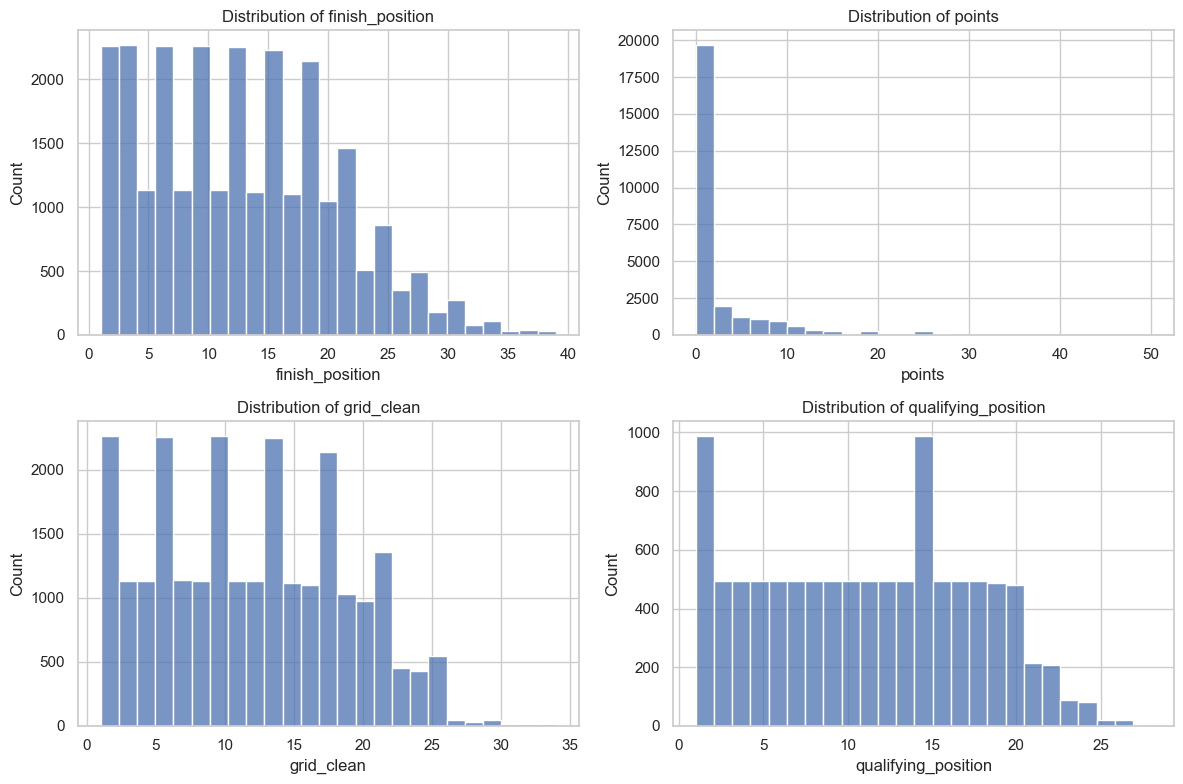

In [12]:
import os
import matplotlib.pyplot as plt

FIG_DIR = "outputs/figures_05"
os.makedirs(FIG_DIR, exist_ok=True)

OUTCOME_VARS = [
    "finish_position",
    "points",
    "grid_clean",
    "qualifying_position"
]

outcome_plot_df = df_outcomes[OUTCOME_VARS].copy()

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

for ax, col in zip(axes, OUTCOME_VARS):
    series = pd.to_numeric(outcome_plot_df[col], errors="coerce").dropna()

    # use discrete bins for discrete variables
    if col in ["finish_position", "points", "grid_clean", "qualifying_position"]:
        sns.histplot(series, bins=min(series.nunique(), 25), kde=False, ax=ax)
    else:
        sns.histplot(series, kde=True, ax=ax)

    ax.set_title(f"Distribution of {col}")
    ax.set_xlabel(col)
    ax.set_ylabel("Count")

plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "01_outcome_vars_distro.png"), dpi=300, bbox_inches="tight")
plt.show()

*These distributions show that race outcomes in Formula 1 are highly structured rather than random. Finishing position and grid position appear relatively uniform across the field, reflecting the fixed size of the grid, while points are heavily right-skewed, with most drivers earning few or no points. This imbalance highlights a core feature of F1: performance and rewards are concentrated among a small number of top drivers and teams.*

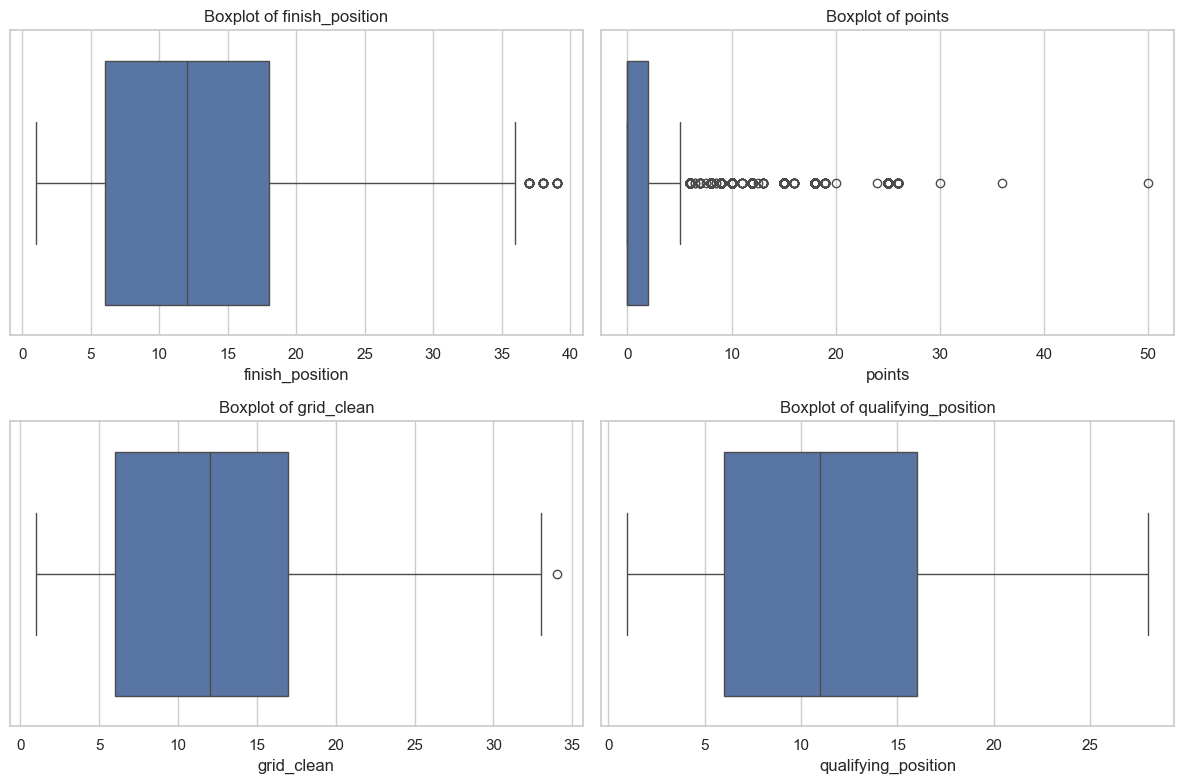

<Figure size 640x480 with 0 Axes>

In [13]:
FIG_DIR = "outputs/figures_05"
os.makedirs(FIG_DIR, exist_ok=True)

import os
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

for ax, col in zip(axes, OUTCOME_VARS):
    series = pd.to_numeric(df_outcomes[col], errors="coerce").dropna()
    sns.boxplot(x=series, ax=ax)
    ax.set_title(f"Boxplot of {col}")
    ax.set_xlabel(col)

plt.tight_layout()
plt.show()

plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "02_boxplots_targets.png"), dpi=300, bbox_inches="tight")
plt.show()

*The boxplots reinforce the asymmetry in race outcomes. While grid and finishing positions are bounded and relatively symmetric, points exhibit extreme outliers, reflecting rare high-scoring performances. This suggests that modeling race success requires handling heavy tails and non-normality, particularly when focusing on performance metrics tied to scoring systems.*

## Strategy Variable Distribution EDA

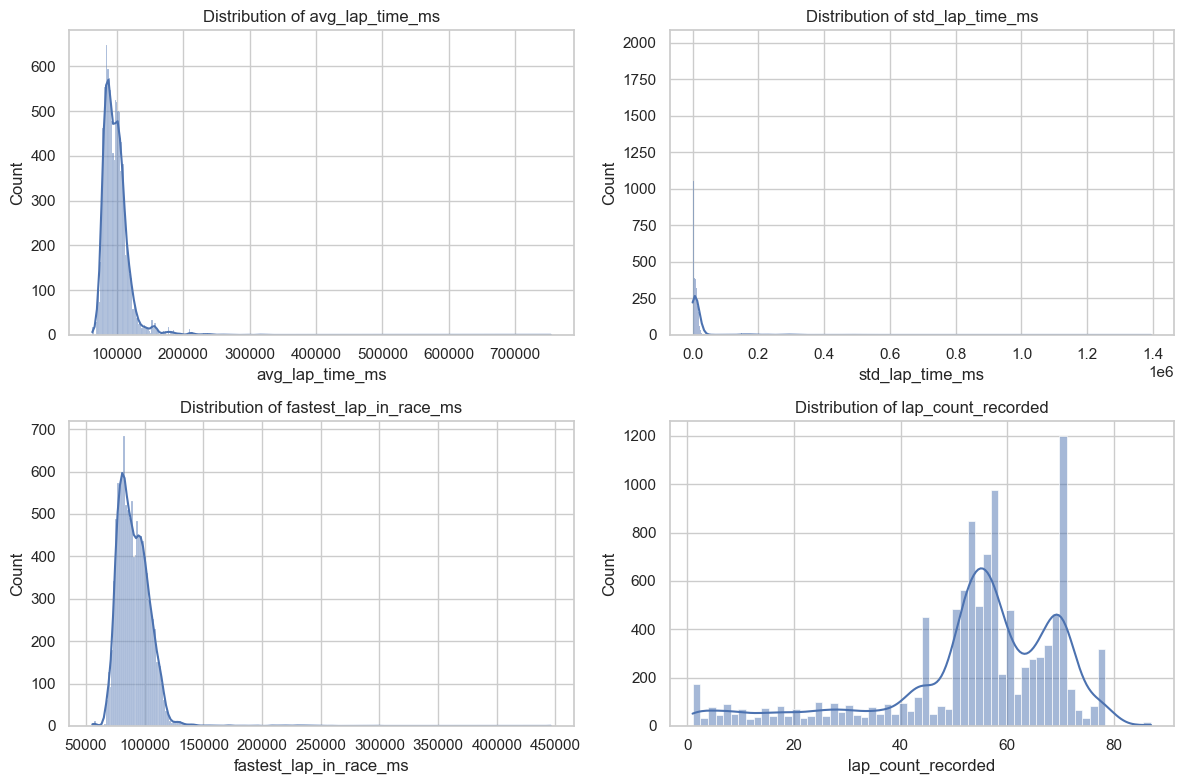

In [14]:
FIG_DIR = "outputs/figures_05"
os.makedirs(FIG_DIR, exist_ok=True)

import os
import matplotlib.pyplot as plt

STRATEGY_VARS_CORE = [
    "avg_lap_time_ms",
    "std_lap_time_ms",
    "fastest_lap_in_race_ms",
    "lap_count_recorded"
]

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

for ax, col in zip(axes, STRATEGY_VARS_CORE):
    series = pd.to_numeric(df_strategy[col], errors="coerce").dropna()
    sns.histplot(series, kde=True, ax=ax)
    ax.set_title(f"Distribution of {col}")
    ax.set_xlabel(col)
    ax.set_ylabel("Count")

plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "03_strategy_vars_distro.png"), dpi=300, bbox_inches="tight")
plt.show()

*Lap-based metrics such as average lap time and fastest lap are strongly right-skewed, with long tails driven by anomalies like safety cars, retirements, or data irregularities. Lap counts show a multimodal structure, reflecting variation across circuits and race formats. These patterns indicate that race dynamics are not uniform and must be contextualized by track and race conditions.*

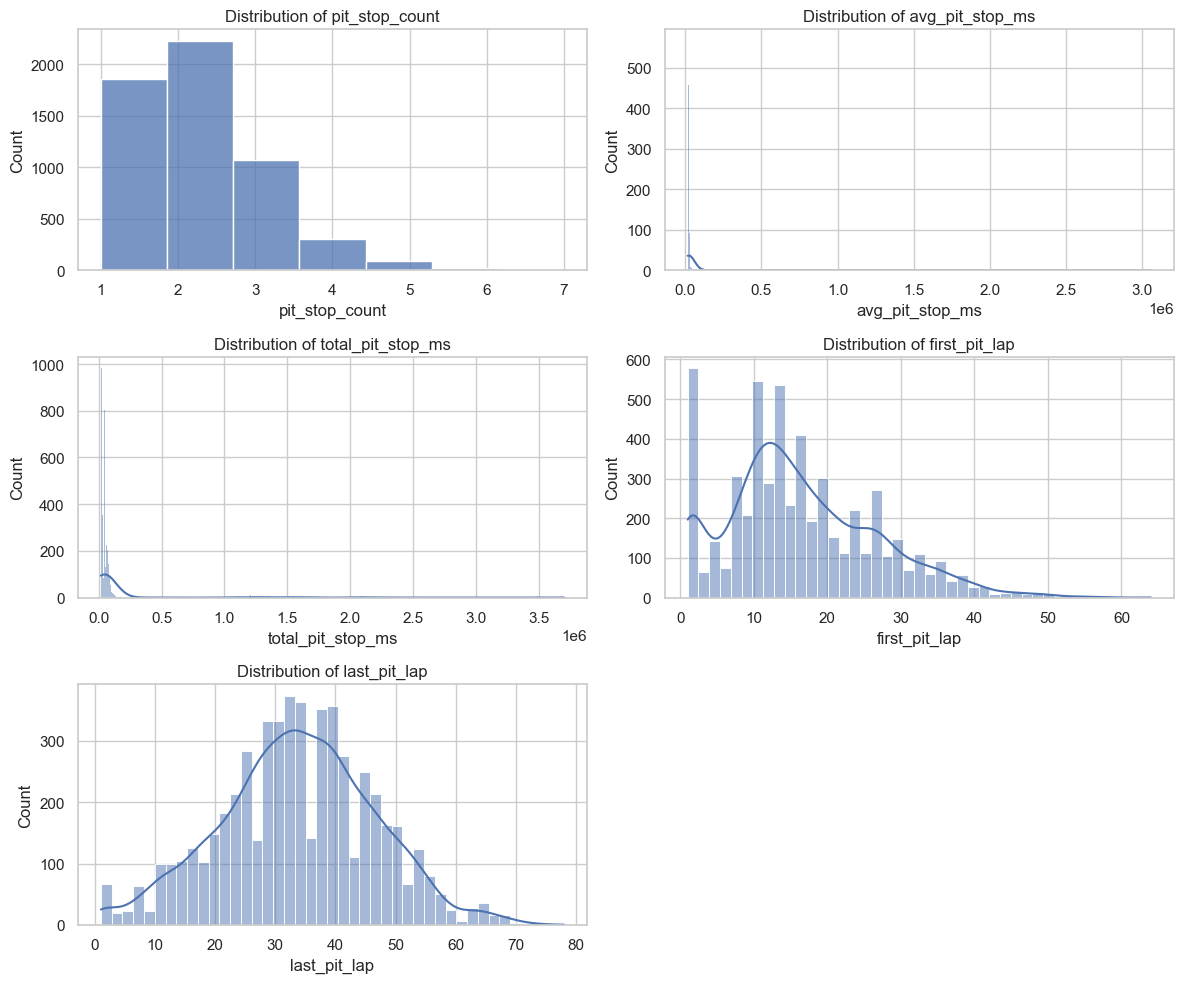

In [15]:
import os
import matplotlib.pyplot as plt

FIG_DIR = "outputs/figures_05"
os.makedirs(FIG_DIR, exist_ok=True)

PIT_VARS = [
    "pit_stop_count",
    "avg_pit_stop_ms",
    "total_pit_stop_ms",
    "first_pit_lap",
    "last_pit_lap"
]

pit_df = df_strategy[PIT_VARS].apply(pd.to_numeric, errors="coerce")

fig, axes = plt.subplots(3, 2, figsize=(12, 10))
axes = axes.flatten()

for i, col in enumerate(PIT_VARS):
    series = pit_df[col].dropna()

    if col == "pit_stop_count":
        sns.histplot(series, bins=min(series.nunique(), 15), kde=False, ax=axes[i])
    else:
        sns.histplot(series, kde=True, ax=axes[i])

    axes[i].set_title(f"Distribution of {col}")
    axes[i].set_xlabel(col)
    axes[i].set_ylabel("Count")

# remove unused subplot
fig.delaxes(axes[-1])

plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "04_pit_vars_distro.png"), dpi=300, bbox_inches="tight")
plt.show()

*Pit-related variables exhibit extreme right skew and heavy tails, particularly for total and average pit stop durations. While most pit stops are tightly clustered, rare but impactful events—such as long delays or mechanical issues—create significant outliers. This reinforces the idea that pit strategy introduces both consistency and high-impact variability into race outcomes.*

## Transformations

In [16]:
from scipy import stats
from sklearn.preprocessing import PowerTransformer

col = "avg_pit_stop_ms"

series = pd.to_numeric(df_strategy[col], errors="coerce").dropna()

# Ensure strictly positive for Box-Cox
series_pos = series[series > 0]

In [17]:
# Log transform
log_series = np.log1p(series)

# Box-Cox (requires strictly positive values)
boxcox_transformed, boxcox_lambda = stats.boxcox(series_pos)

# Yeo-Johnson (handles full data)
pt = PowerTransformer(method="yeo-johnson")
yeojohnson_series = pt.fit_transform(series.values.reshape(-1, 1)).flatten()

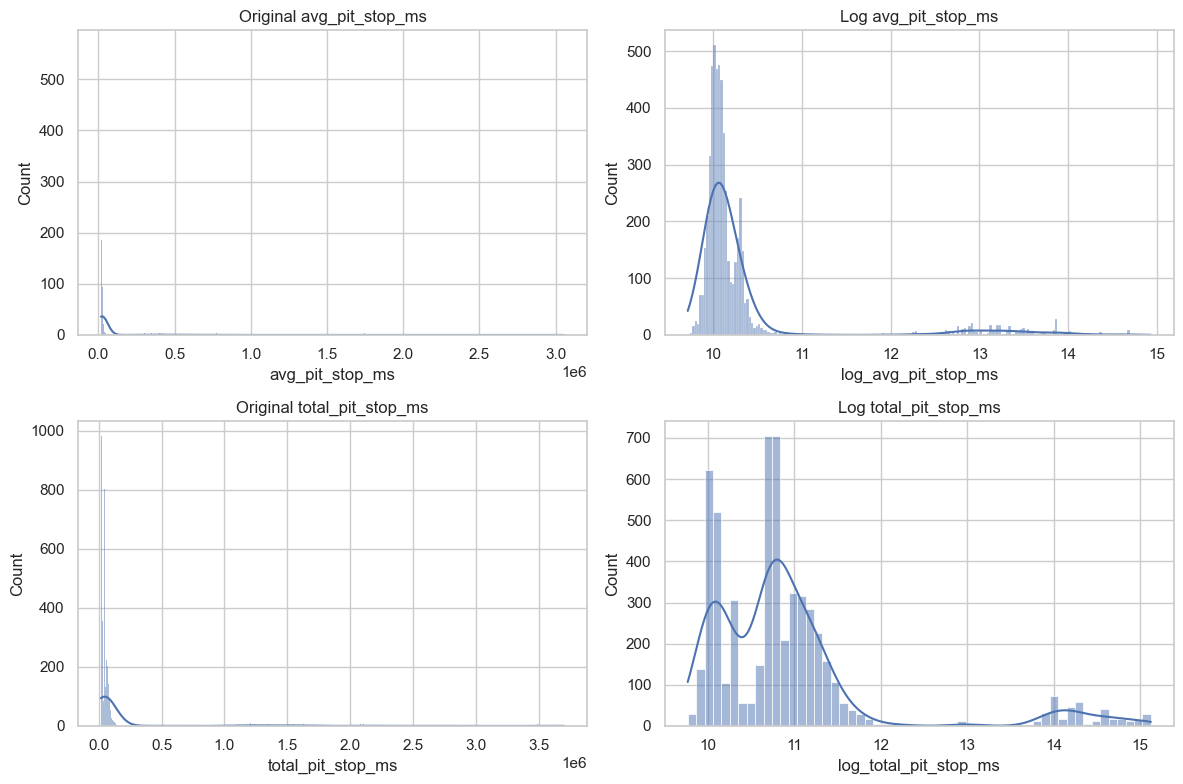

In [18]:
FIG_DIR = "outputs/figures_05"
os.makedirs(FIG_DIR, exist_ok=True)

df_strategy["log_avg_pit_stop_ms"] = np.log1p(pd.to_numeric(df_strategy["avg_pit_stop_ms"], errors="coerce"))
df_strategy["log_total_pit_stop_ms"] = np.log1p(pd.to_numeric(df_strategy["total_pit_stop_ms"], errors="coerce"))

fig, axes = plt.subplots(2, 2, figsize=(12, 8))

sns.histplot(df_strategy["avg_pit_stop_ms"].dropna(), kde=True, ax=axes[0, 0])
axes[0, 0].set_title("Original avg_pit_stop_ms")

sns.histplot(df_strategy["log_avg_pit_stop_ms"].dropna(), kde=True, ax=axes[0, 1])
axes[0, 1].set_title("Log avg_pit_stop_ms")

sns.histplot(df_strategy["total_pit_stop_ms"].dropna(), kde=True, ax=axes[1, 0])
axes[1, 0].set_title("Original total_pit_stop_ms")

sns.histplot(df_strategy["log_total_pit_stop_ms"].dropna(), kde=True, ax=axes[1, 1])
axes[1, 1].set_title("Log total_pit_stop_ms")

plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "05_var_transform_hist.png"), dpi=300, bbox_inches="tight")
plt.show()

*Log transformations reduce skewness and compress extreme values, making distributions more symmetric and interpretable. However, residual skewness remains, indicating that simple log transformations are insufficient for fully normalizing F1 timing data.*

In [19]:
def normality_tests(x, name=""):
    x = pd.Series(x).dropna()

    results = {
        "variable": name,
        "skewness": stats.skew(x),
        "kurtosis": stats.kurtosis(x),
        "shapiro_p": stats.shapiro(x.sample(min(len(x), 5000)))[1],  # sample for speed
        "dagostino_p": stats.normaltest(x)[1],
        "anderson_stat": stats.anderson(x).statistic
    }

    return results

In [20]:
#compare transformations
results = pd.DataFrame([
    normality_tests(series, "original"),
    normality_tests(log_series, "log"),
    normality_tests(boxcox_transformed, "boxcox"),
    normality_tests(yeojohnson_series, "yeojohnson")
])

results

/var/folders/cg/wc2pq_yj52nbzwtdflk50zzc0000gn/T/ipykernel_48294/3428605293.py:10: FutureWarning: As of SciPy 1.17, users must choose a p-value calculation method by providing the `method` parameter. `method='interpolate'` interpolates the p-value from pre-calculated tables; `method` may also be an instance of `MonteCarloMethod` to approximate the p-value via Monte Carlo simulation. When `method` is specified, the result object will include a `pvalue` attribute and not attributes `critical_value`, `significance_level`, or `fit_result`. Beginning in 1.19.0, these other attributes will no longer be available, and a p-value will always be computed according to one of the available `method` options.
  "anderson_stat": stats.anderson(x).statistic


,variable,skewness,kurtosis,shapiro_p,dagostino_p,anderson_stat
0,original,6.187065,49.948050,6.546779e-89,0.000000e+00,1703.221990
1,log,3.299785,9.767950,1.684612e-82,0.000000e+00,1242.122090
2,boxcox,0.915128,0.925678,1.891970e-45,1.491025e-147,134.886481
3,yeojohnson,0.915185,0.925759,3.894268e-45,1.441655e-147,134.896519


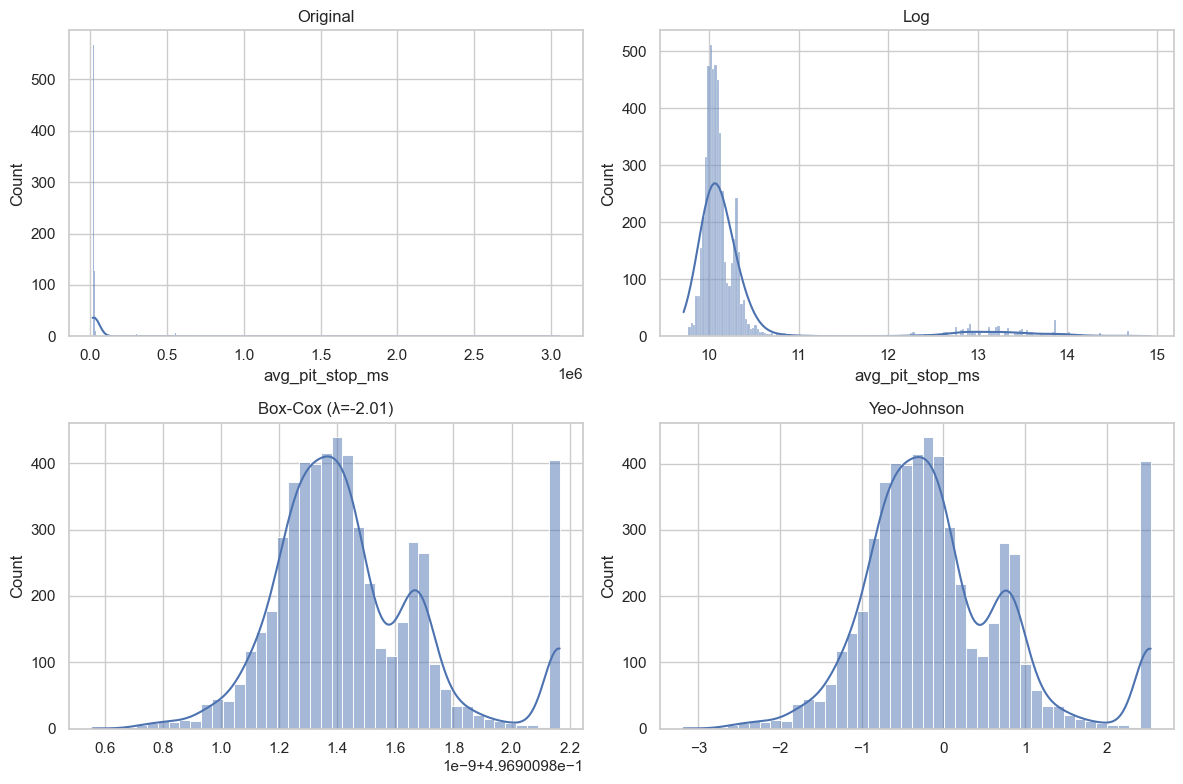

In [21]:
FIG_DIR = "outputs/figures_05"
os.makedirs(FIG_DIR, exist_ok=True)

#comparison of transformations - histograms
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

sns.histplot(series, kde=True, ax=axes[0, 0])
axes[0, 0].set_title("Original")

sns.histplot(log_series, kde=True, ax=axes[0, 1])
axes[0, 1].set_title("Log")

sns.histplot(boxcox_transformed, kde=True, ax=axes[1, 0])
axes[1, 0].set_title(f"Box-Cox (λ={boxcox_lambda:.2f})")

sns.histplot(yeojohnson_series, kde=True, ax=axes[1, 1])
axes[1, 1].set_title("Yeo-Johnson")

plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "06_var_transform_compare.png"), dpi=300, bbox_inches="tight")
plt.show()

*More flexible transformations such as Box-Cox and Yeo-Johnson substantially improve distributional symmetry compared to log transformations. These methods better stabilize variance and reduce skewness, making them more suitable for statistical modeling and inference in this context.*

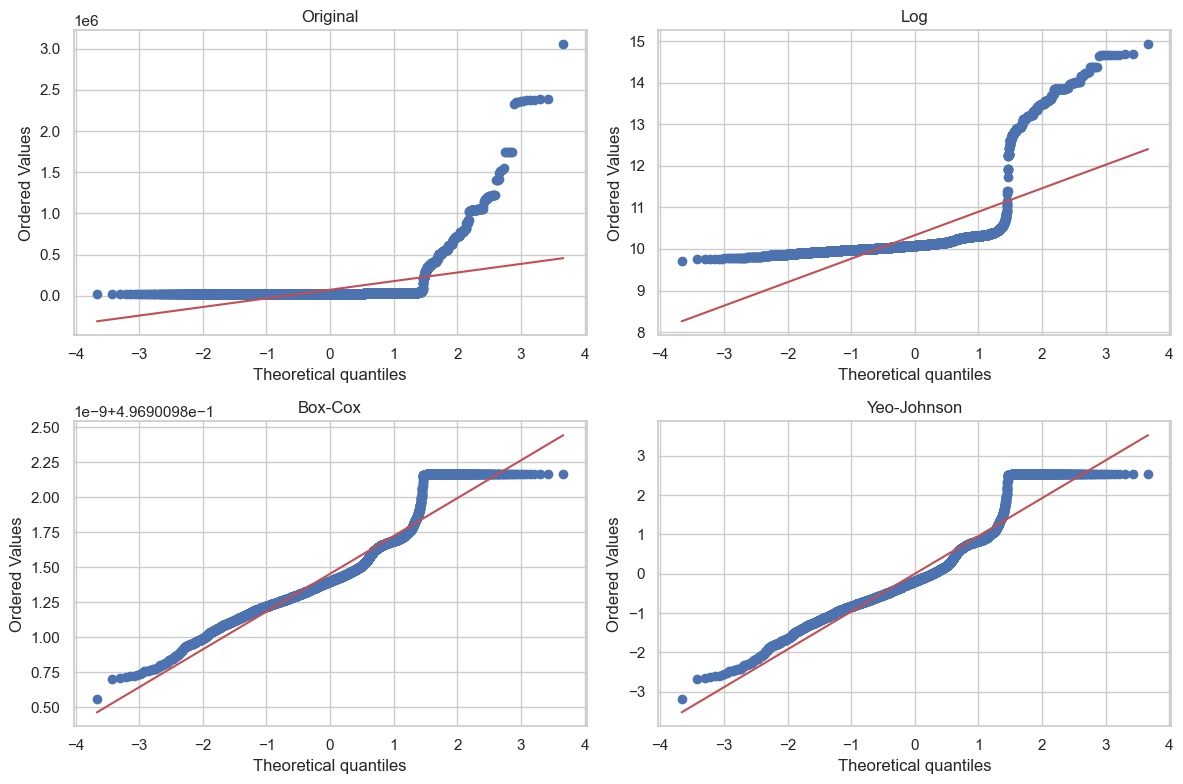

In [22]:
FIG_DIR = "outputs/figures_05"
os.makedirs(FIG_DIR, exist_ok=True)

#Q-Q Plots
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

stats.probplot(series, dist="norm", plot=axes[0, 0])
axes[0, 0].set_title("Original")

stats.probplot(log_series, dist="norm", plot=axes[0, 1])
axes[0, 1].set_title("Log")

stats.probplot(boxcox_transformed, dist="norm", plot=axes[1, 0])
axes[1, 0].set_title("Box-Cox")

stats.probplot(yeojohnson_series, dist="norm", plot=axes[1, 1])
axes[1, 1].set_title("Yeo-Johnson")

plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "07_q_q_plots_transform_compare.png"), dpi=300, bbox_inches="tight")
plt.show()

*Q-Q plots reveal strong deviations from normality in the original data, particularly in the tails. Log transformations improve alignment but still exhibit curvature, while Box-Cox and Yeo-Johnson transformations produce distributions that more closely follow the theoretical normal line, especially in the central range.*

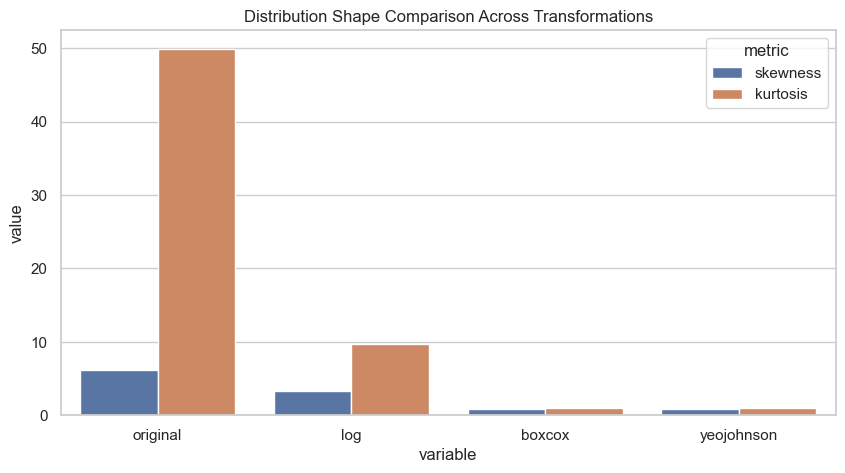

In [23]:
FIG_DIR = "outputs/figures_05"
os.makedirs(FIG_DIR, exist_ok=True)

#Side by side skew/kurtosis comparison
results_melt = results.melt(
    id_vars="variable",
    value_vars=["skewness", "kurtosis"],
    var_name="metric",
    value_name="value"
)

plt.figure(figsize=(10, 5))
sns.barplot(data=results_melt, x="variable", y="value", hue="metric")
plt.title("Distribution Shape Comparison Across Transformations")
plt.savefig(os.path.join(FIG_DIR, "07_skew_kurtosis_compare_plots.png"), dpi=300, bbox_inches="tight")
plt.show()

In [24]:
from scipy import stats
from sklearn.preprocessing import PowerTransformer

def transformation_comparison(df, col):
    series = pd.to_numeric(df[col], errors="coerce").dropna()
    series = series[np.isfinite(series)]

    # keep positive subset for Box-Cox
    series_pos = series[series > 0]

    # transforms
    log_series = np.log1p(series)
    yeojohnson = PowerTransformer(method="yeo-johnson")
    yeojohnson_series = yeojohnson.fit_transform(series.to_frame()).flatten()

    boxcox_transformed = None
    boxcox_lambda = None
    if len(series_pos) > 0:
        boxcox_transformed, boxcox_lambda = stats.boxcox(series_pos)

    def summarize(x, name):
        x = pd.Series(x).dropna()
        return {
            "transform": name,
            "count": x.shape[0],
            "mean": x.mean(),
            "std": x.std(),
            "skewness": stats.skew(x),
            "kurtosis": stats.kurtosis(x),
            "shapiro_p": stats.shapiro(x.sample(min(len(x), 5000), random_state=42))[1],
            "dagostino_p": stats.normaltest(x)[1],
            "anderson_stat": stats.anderson(x).statistic
        }

    rows = [summarize(series, "original"), summarize(log_series, "log1p"), summarize(yeojohnson_series, "yeo-johnson")]

    if boxcox_transformed is not None:
        rows.append(summarize(boxcox_transformed, f"box-cox (λ={boxcox_lambda:.2f})"))

    summary_df = pd.DataFrame(rows)

    # plots
    fig, axes = plt.subplots(2, 2, figsize=(12, 8))
    axes = axes.flatten()

    plot_series = [
        ("Original", series),
        ("Log1p", log_series),
        ("Yeo-Johnson", yeojohnson_series),
    ]

    if boxcox_transformed is not None:
        plot_series.append((f"Box-Cox (λ={boxcox_lambda:.2f})", boxcox_transformed))
    else:
        plot_series.append(("Box-Cox unavailable", pd.Series(dtype=float)))

    for ax, (title, values) in zip(axes, plot_series):
        if len(values) > 0:
            sns.histplot(values, kde=True, ax=ax)
        ax.set_title(f"{col} — {title}")
        ax.set_xlabel("")
        ax.set_ylabel("Count")

    plt.tight_layout()
    plt.show()

    fig, axes = plt.subplots(2, 2, figsize=(12, 8))
    axes = axes.flatten()

    for ax, (title, values) in zip(axes, plot_series):
        if len(values) > 0:
            stats.probplot(values, dist="norm", plot=ax)
        ax.set_title(f"Q-Q: {title}")

    plt.tight_layout()
    plt.show()

    return summary_df

/var/folders/cg/wc2pq_yj52nbzwtdflk50zzc0000gn/T/ipykernel_48294/2537595145.py:32: FutureWarning: As of SciPy 1.17, users must choose a p-value calculation method by providing the `method` parameter. `method='interpolate'` interpolates the p-value from pre-calculated tables; `method` may also be an instance of `MonteCarloMethod` to approximate the p-value via Monte Carlo simulation. When `method` is specified, the result object will include a `pvalue` attribute and not attributes `critical_value`, `significance_level`, or `fit_result`. Beginning in 1.19.0, these other attributes will no longer be available, and a p-value will always be computed according to one of the available `method` options.
  "anderson_stat": stats.anderson(x).statistic


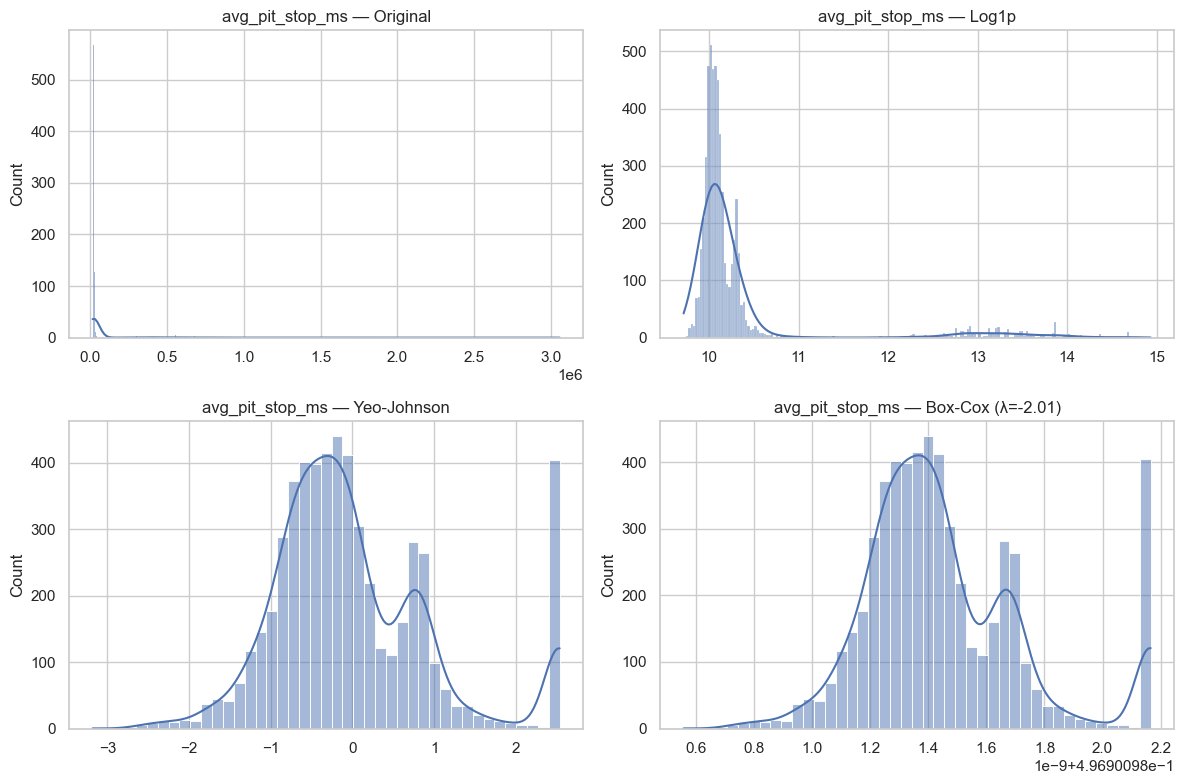

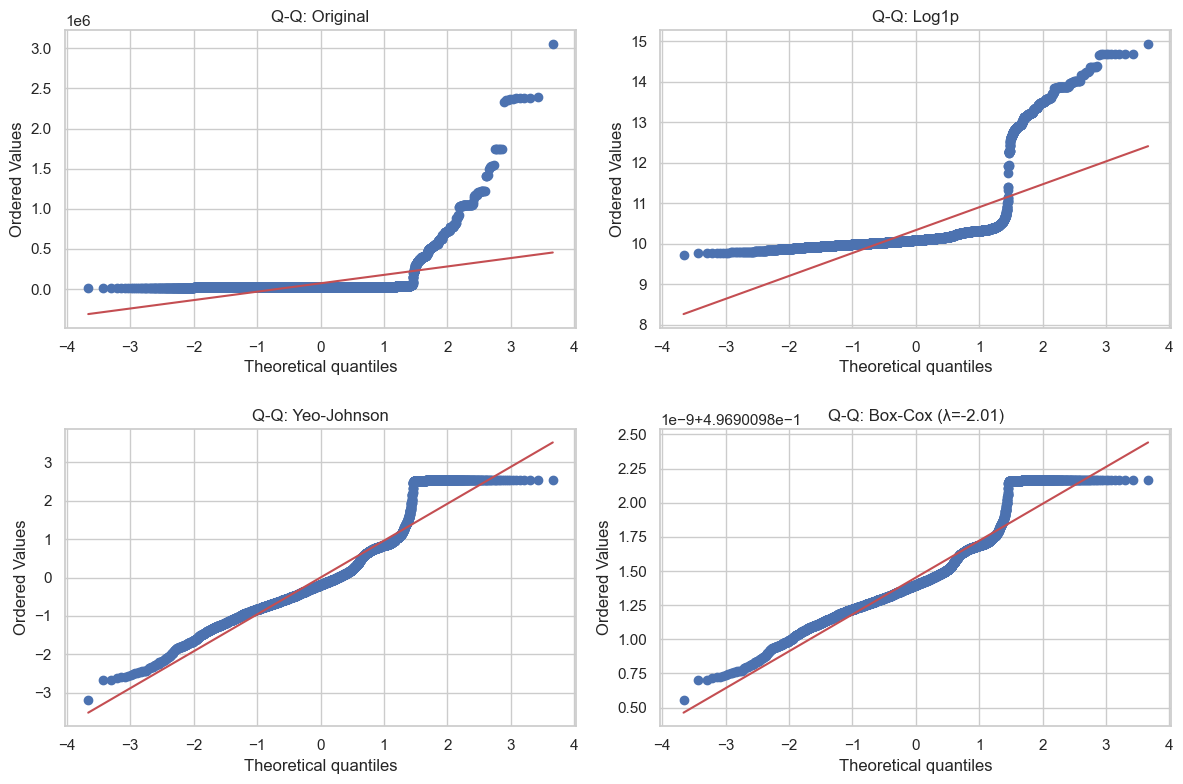

<Figure size 640x480 with 0 Axes>

In [25]:
FIG_DIR = "outputs/figures_05"
os.makedirs(FIG_DIR, exist_ok=True)

pit_transform_summary = transformation_comparison(df_strategy, "avg_pit_stop_ms")
pit_transform_summary

plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "08_transform_summary_pit.png"), dpi=300, bbox_inches="tight")
plt.show()

/var/folders/cg/wc2pq_yj52nbzwtdflk50zzc0000gn/T/ipykernel_48294/2537595145.py:32: FutureWarning: As of SciPy 1.17, users must choose a p-value calculation method by providing the `method` parameter. `method='interpolate'` interpolates the p-value from pre-calculated tables; `method` may also be an instance of `MonteCarloMethod` to approximate the p-value via Monte Carlo simulation. When `method` is specified, the result object will include a `pvalue` attribute and not attributes `critical_value`, `significance_level`, or `fit_result`. Beginning in 1.19.0, these other attributes will no longer be available, and a p-value will always be computed according to one of the available `method` options.
  "anderson_stat": stats.anderson(x).statistic


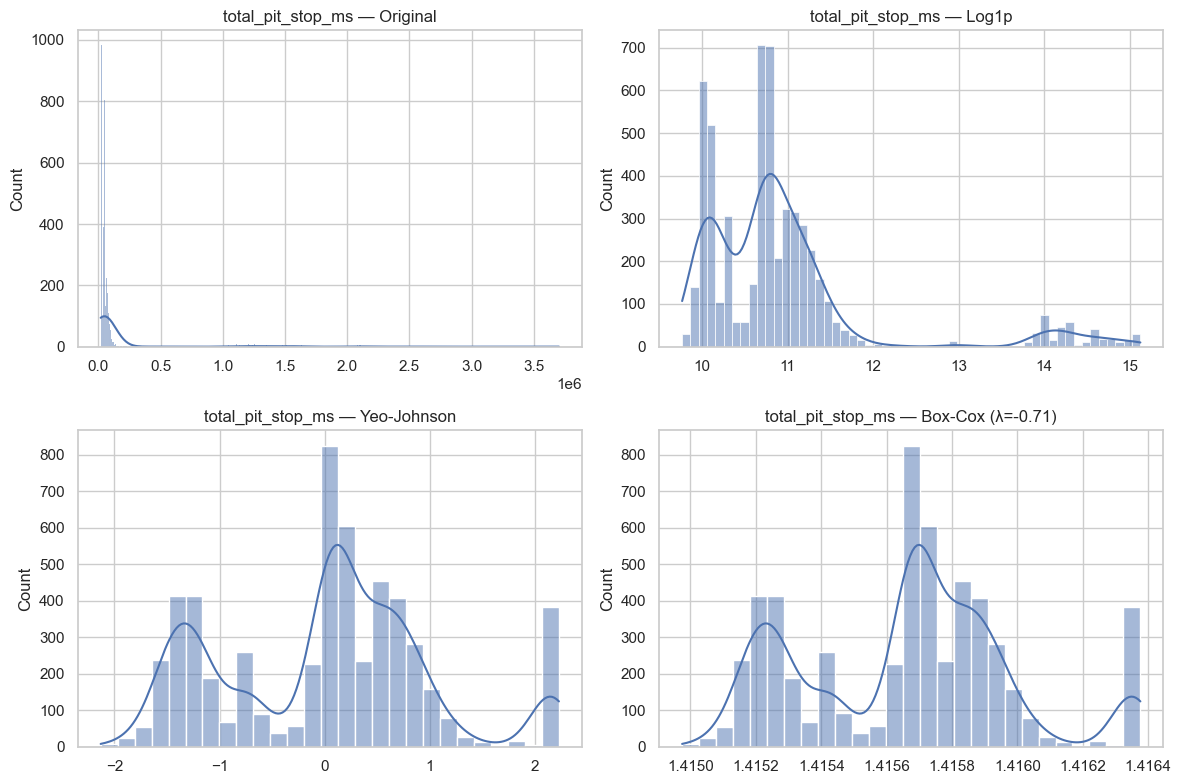

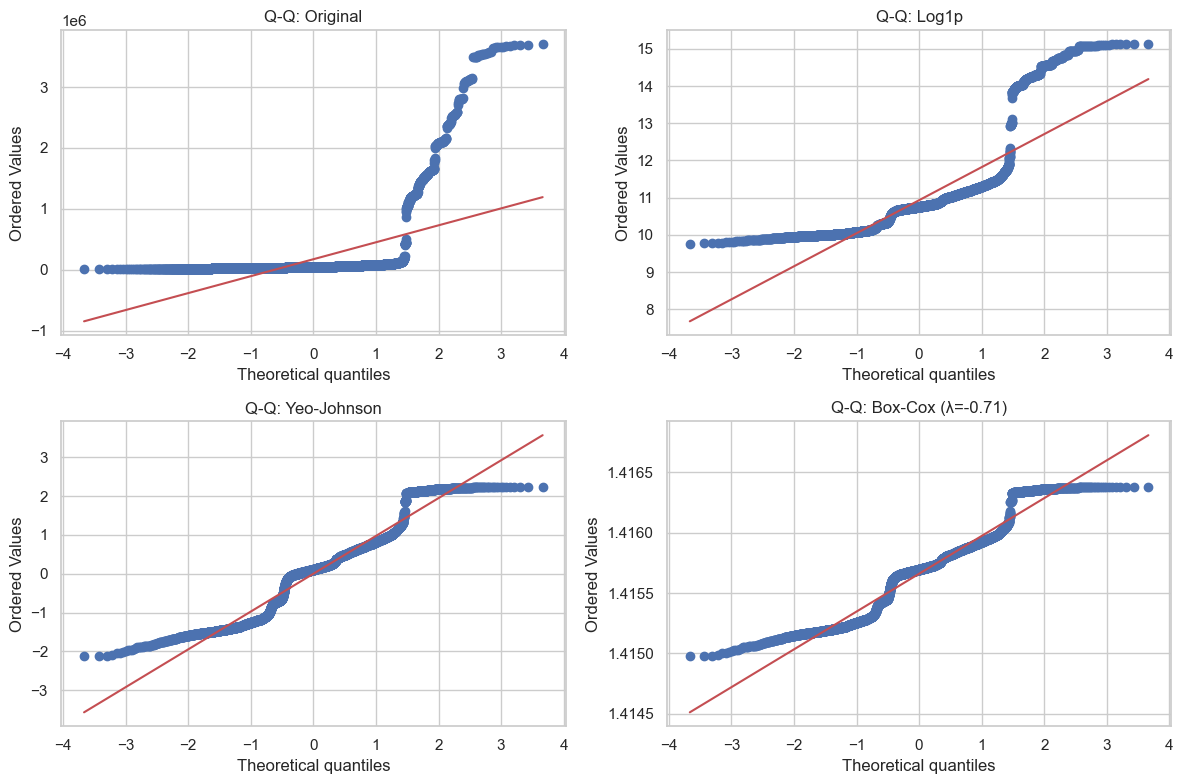

<Figure size 640x480 with 0 Axes>

In [26]:
FIG_DIR = "outputs/figures_05"
os.makedirs(FIG_DIR, exist_ok=True)

total_pit_transform_summary = transformation_comparison(df_strategy, "total_pit_stop_ms")
total_pit_transform_summary

plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "09_transform_summary_total_pit.png"), dpi=300, bbox_inches="tight")
plt.show()

*Total pit stop duration shows extreme heavy-tailed behavior in its raw form. Transformations significantly improve normality, with Yeo-Johnson providing the most consistent fit across quantiles, suggesting it is better suited for modeling aggregated race strategy effects.*

/var/folders/cg/wc2pq_yj52nbzwtdflk50zzc0000gn/T/ipykernel_48294/2537595145.py:32: FutureWarning: As of SciPy 1.17, users must choose a p-value calculation method by providing the `method` parameter. `method='interpolate'` interpolates the p-value from pre-calculated tables; `method` may also be an instance of `MonteCarloMethod` to approximate the p-value via Monte Carlo simulation. When `method` is specified, the result object will include a `pvalue` attribute and not attributes `critical_value`, `significance_level`, or `fit_result`. Beginning in 1.19.0, these other attributes will no longer be available, and a p-value will always be computed according to one of the available `method` options.
  "anderson_stat": stats.anderson(x).statistic


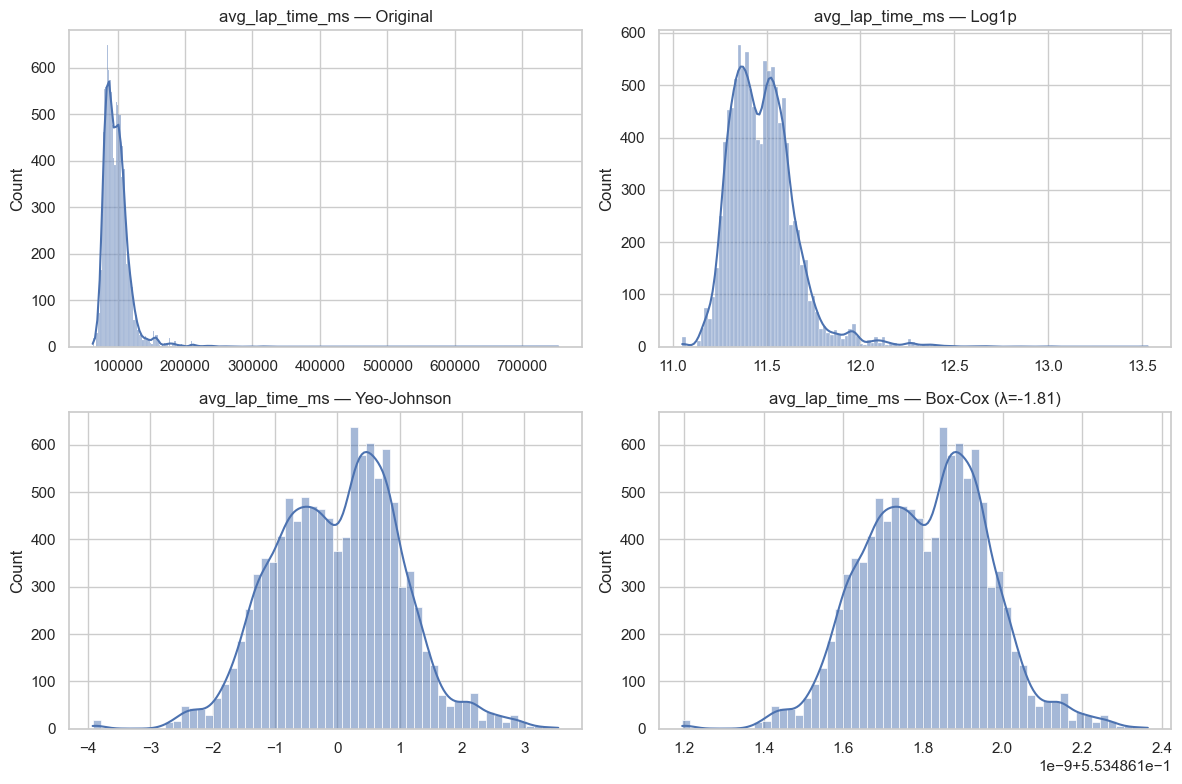

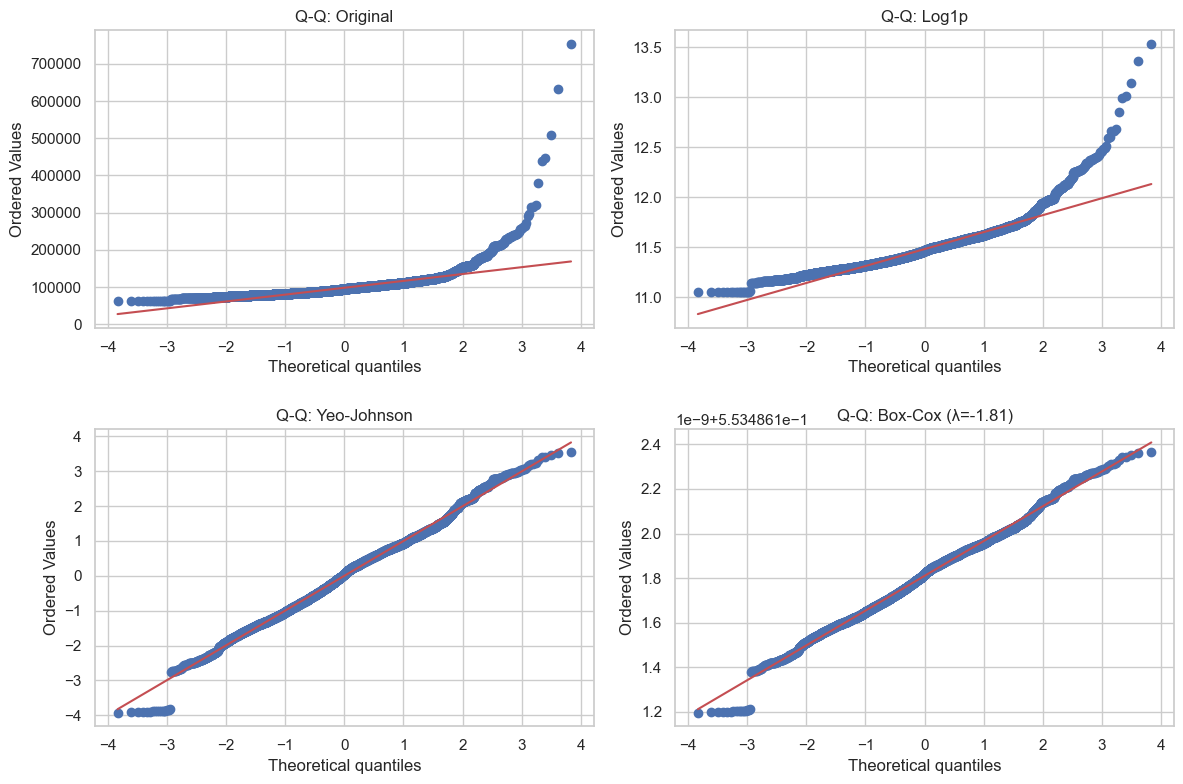

<Figure size 640x480 with 0 Axes>

In [27]:
FIG_DIR = "outputs/figures_05"
os.makedirs(FIG_DIR, exist_ok=True)

lap_transform_summary = transformation_comparison(df_strategy, "avg_lap_time_ms")
lap_transform_summary

plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "10_transform_summary_lap.png"), dpi=300, bbox_inches="tight")
plt.show()

*This comparison quantifies how transformations reduce skewness and kurtosis. The original variables exhibit extreme non-normality, while Box-Cox and Yeo-Johnson transformations bring both metrics closer to zero, indicating more stable and model-friendly distributions.*

*Lap time distributions, while still skewed, respond well to transformation. Box-Cox and Yeo-Johnson reduce tail distortion and improve normal approximation, enabling more reliable statistical comparisons across drivers and races.*

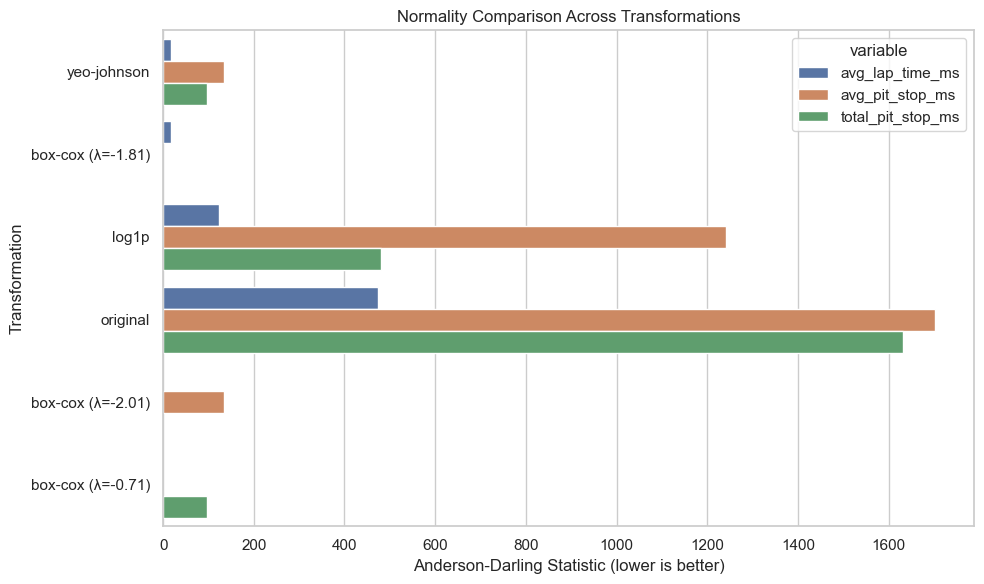

In [54]:
transform_decision = pd.concat([
    pit_transform_summary.assign(variable="avg_pit_stop_ms"),
    total_pit_transform_summary.assign(variable="total_pit_stop_ms"),
    lap_transform_summary.assign(variable="avg_lap_time_ms")
], ignore_index=True)

transform_decision = transform_decision[
    ["variable", "transform", "skewness", "kurtosis", "shapiro_p", "dagostino_p", "anderson_stat"]
].sort_values(["variable", "anderson_stat"])

plt.figure(figsize=(10, 6))
sns.barplot(
    data=transform_decision,
    x="anderson_stat",
    y="transform",
    hue="variable"
)
plt.title("Normality Comparison Across Transformations")
plt.xlabel("Anderson-Darling Statistic (lower is better)")
plt.ylabel("Transformation")
plt.tight_layout()

FIG_DIR = "outputs/figures_05"
os.makedirs(FIG_DIR, exist_ok=True)
plt.savefig(os.path.join(FIG_DIR, "11_transformation_normality_comparison.png"), dpi=300, bbox_inches="tight")
plt.show()

*Across pit-related variables, transformation effectiveness varies, but flexible methods consistently outperform simple logs. This highlights the importance of selecting transformations based on empirical distribution shape rather than defaulting to standard approaches.*

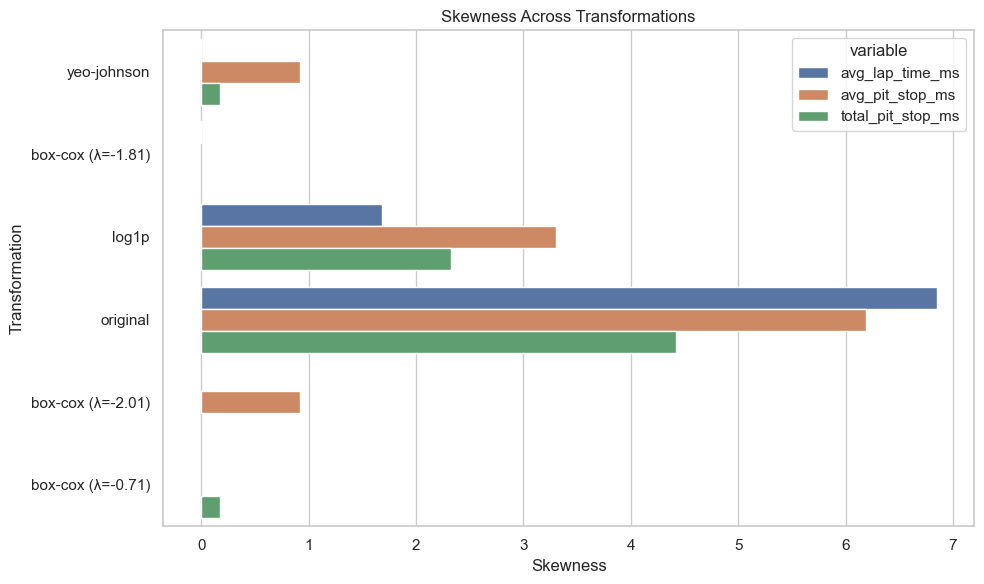

In [55]:
plt.figure(figsize=(10, 6))
sns.barplot(
    data=transform_decision,
    x="skewness",
    y="transform",
    hue="variable"
)
plt.title("Skewness Across Transformations")
plt.xlabel("Skewness")
plt.ylabel("Transformation")
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "12_transformation_skewness_comparison.png"), dpi=300, bbox_inches="tight")
plt.show()

*Across pit-related variables, transformation effectiveness varies, but flexible methods consistently outperform simple logs. This highlights the importance of selecting transformations based on empirical distribution shape rather than defaulting to standard approaches.*

### Transformation takeaways

Across pit stop and lap-time variables, Box-Cox and Yeo-Johnson consistently reduce skewness and kurtosis more effectively than log transforms alone. For downstream modeling, Yeo-Johnson is often the most convenient default because it is more flexible when zeros or edge cases are present.

In [29]:
from scipy.stats import skew, kurtosis

def shape_summary(df, variables, name=""):
    rows = []

    for col in variables:
        series = pd.to_numeric(df[col], errors="coerce").dropna()

        if series.empty:
            continue

        rows.append({
            "variable": col,
            "dataset": name,
            "count": series.shape[0],
            "mean": series.mean(),
            "std": series.std(),
            "min": series.min(),
            "max": series.max(),
            "skewness": skew(series),
            "kurtosis": kurtosis(series)
        })

    return pd.DataFrame(rows).sort_values("skewness", ascending=False)

In [30]:
shape_outcomes = shape_summary(df_outcomes, OUTCOME_VARS, "outcomes")
shape_outcomes

,variable,dataset,count,mean,std,min,max,skewness,kurtosis
1,points,outcomes,26759,1.987632,4.351209,0.0,50.0,3.043936,10.730907
0,finish_position,outcomes,26759,12.794051,7.665951,1.0,39.0,0.399360,-0.474495
2,grid_clean,outcomes,25121,11.860834,6.830260,1.0,34.0,0.205085,-0.880242
3,qualifying_position,outcomes,10494,11.195826,6.260374,1.0,28.0,0.080556,-1.074988


In [31]:
shape_strategy = shape_summary(df_strategy, STRATEGY_VARS_CORE, "strategy")
shape_strategy

,variable,dataset,count,mean,std,min,max,skewness,kurtosis
1,std_lap_time_ms,strategy,10926,22662.749717,73150.958097,166.170094,1.394070e+06,7.816241,82.242238
0,avg_lap_time_ms,strategy,11041,98540.311539,22402.558441,62932.344828,7.534930e+05,6.853179,126.543370
2,fastest_lap_in_race_ms,strategy,11041,90834.403496,14605.704254,55404.000000,4.460360e+05,3.810684,51.939914
3,lap_count_recorded,strategy,11041,53.353953,17.412589,1.000000,8.700000e+01,-1.268327,1.282315


In [32]:
shape_pit = shape_summary(df_strategy, PIT_VARS, "pit")
shape_pit

,variable,dataset,count,mean,std,min,max,skewness,kurtosis
1,avg_pit_stop_ms,pit,5575,71885.239934,205491.140261,16549.0,3055732.0,6.187065,49.948050
2,total_pit_stop_ms,pit,5575,173839.634978,496963.064246,17434.0,3703013.0,4.425547,20.749362
0,pit_stop_count,pit,5575,2.039641,0.989017,1.0,7.0,1.023438,1.277907
3,first_pit_lap,pit,5575,16.395157,10.282993,1.0,64.0,0.679463,0.318324
4,last_pit_lap,pit,5575,33.643049,12.936513,1.0,78.0,-0.049231,-0.068618


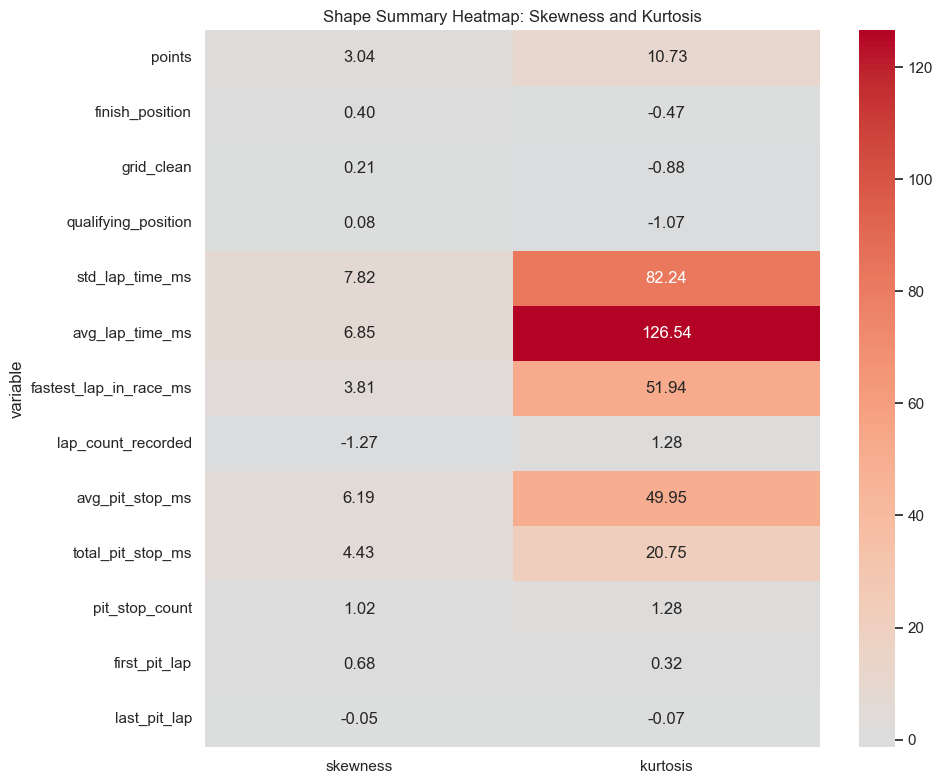

In [57]:
import os
import matplotlib.pyplot as plt
import seaborn as sns

FIG_DIR = "outputs/figures_05"
os.makedirs(FIG_DIR, exist_ok=True)

shape_all = pd.concat([shape_outcomes, shape_strategy, shape_pit], ignore_index=True)

shape_heatmap = shape_all.set_index("variable")[["skewness", "kurtosis"]]

plt.figure(figsize=(10, 8))
sns.heatmap(shape_heatmap, annot=True, cmap="coolwarm", center=0, fmt=".2f")
plt.title("Shape Summary Heatmap: Skewness and Kurtosis")
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "13.1_shape_summary_heatmap.png"), dpi=300, bbox_inches="tight")
plt.show()

*Lap-based metrics benefit from transformation, though less dramatically than pit variables. This reflects a balance between structured race pace and occasional extreme deviations.*

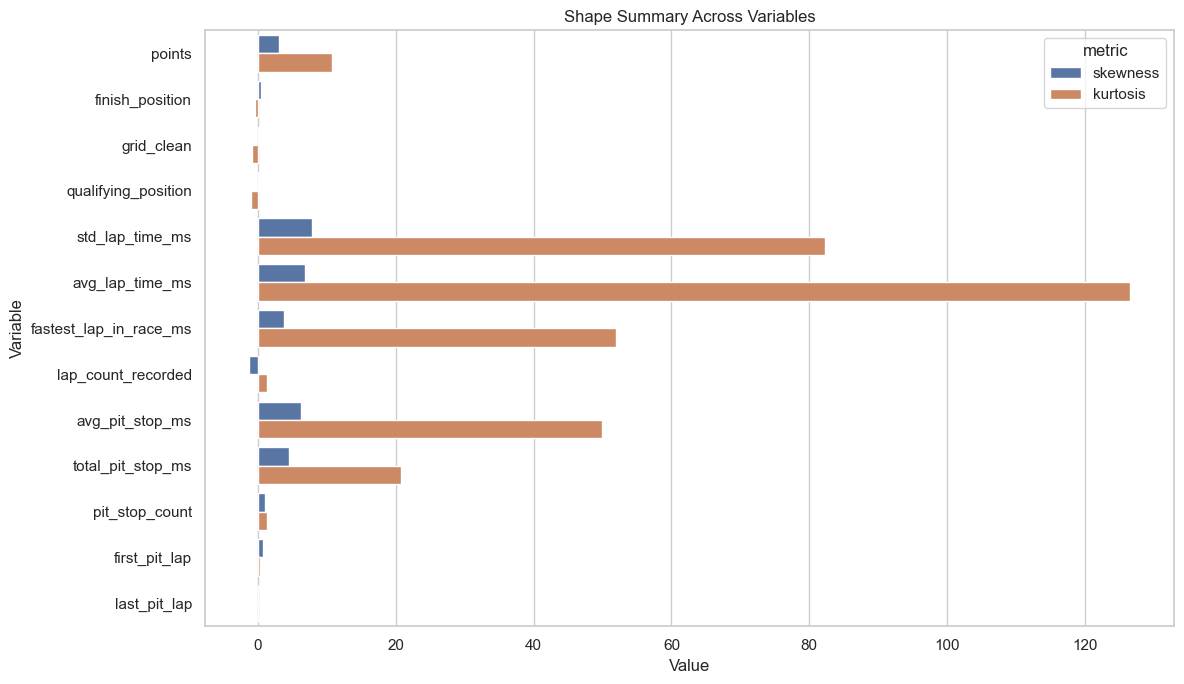

In [58]:
shape_all = pd.concat([shape_outcomes, shape_strategy, shape_pit], ignore_index=True)

shape_plot = shape_all.melt(
    id_vars=["variable", "dataset"],
    value_vars=["skewness", "kurtosis"],
    var_name="metric",
    value_name="value"
)

plt.figure(figsize=(12, 7))
sns.barplot(
    data=shape_plot,
    x="value",
    y="variable",
    hue="metric"
)
plt.title("Shape Summary Across Variables")
plt.xlabel("Value")
plt.ylabel("Variable")
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "13.2_shape_summary_bars.png"), dpi=300, bbox_inches="tight")
plt.show()

<Figure size 1000x600 with 0 Axes>

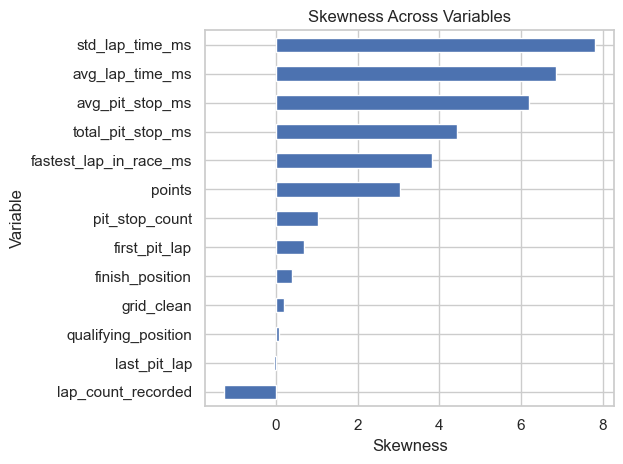

In [34]:
FIG_DIR = "outputs/figures_05"
os.makedirs(FIG_DIR, exist_ok=True)

plt.figure(figsize=(10, 6))

shape_all.sort_values("skewness").plot(
    kind="barh",
    x="variable",
    y="skewness",
    legend=False
)

plt.title("Skewness Across Variables")
plt.xlabel("Skewness")
plt.ylabel("Variable")
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "13_shape_skewness_vars.png"), dpi=300, bbox_inches="tight")
plt.show()

<Figure size 1000x600 with 0 Axes>

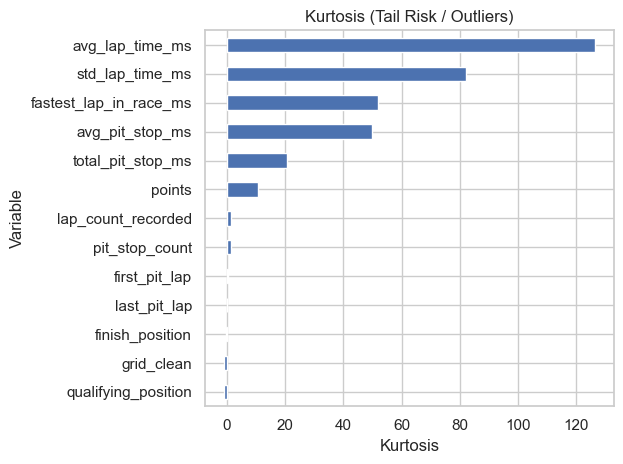

In [35]:
FIG_DIR = "outputs/figures_05"
os.makedirs(FIG_DIR, exist_ok=True)


plt.figure(figsize=(10, 6))

shape_all.sort_values("kurtosis").plot(
    kind="barh",
    x="variable",
    y="kurtosis",
    legend=False
)

plt.title("Kurtosis (Tail Risk / Outliers)")
plt.xlabel("Kurtosis")
plt.ylabel("Variable")
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "14_shape_kurtosis_vars.png"), dpi=300, bbox_inches="tight")
plt.show()

*Statistical tests confirm that transformations significantly improve normality, with Yeo-Johnson often performing best across variables. This provides empirical justification for using transformed features in downstream modeling.*

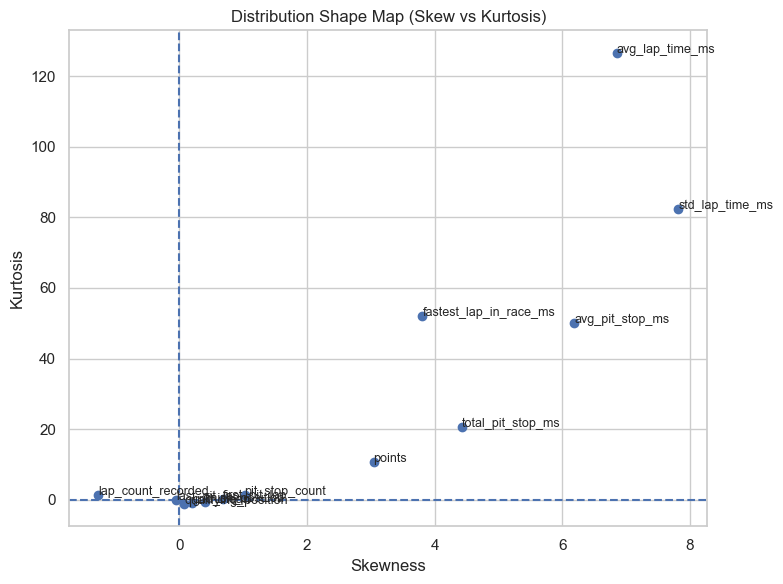

In [36]:
FIG_DIR = "outputs/figures_05"
os.makedirs(FIG_DIR, exist_ok=True)

plt.figure(figsize=(8, 6))

plt.scatter(shape_all["skewness"], shape_all["kurtosis"])

for i, row in shape_all.iterrows():
    plt.text(row["skewness"], row["kurtosis"], row["variable"], fontsize=9)

plt.axvline(0, linestyle="--")
plt.axhline(0, linestyle="--")

plt.title("Distribution Shape Map (Skew vs Kurtosis)")
plt.xlabel("Skewness")
plt.ylabel("Kurtosis")
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "15_shape_skew_vs_kurtosis.png"), dpi=300, bbox_inches="tight")
plt.show()

*Skewness is dramatically reduced after transformation, particularly for pit-related variables. This reduction is critical for improving model stability and ensuring that extreme events do not disproportionately influence results.*

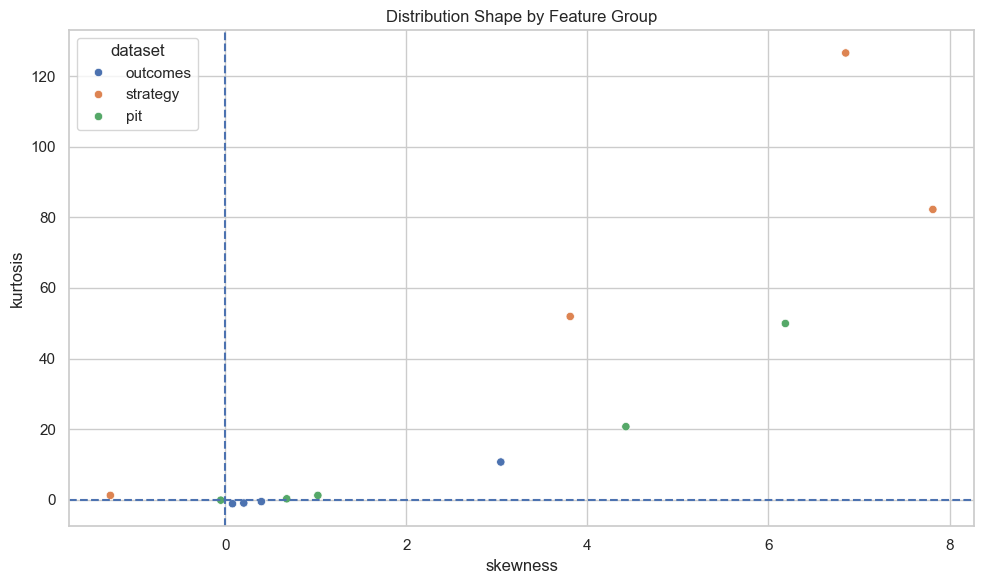

In [37]:
FIG_DIR = "outputs/figures_05"
os.makedirs(FIG_DIR, exist_ok=True)

import seaborn as sns

plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=shape_all,
    x="skewness",
    y="kurtosis",
    hue="dataset"
)

plt.title("Distribution Shape by Feature Group")
plt.axvline(0, linestyle="--")
plt.axhline(0, linestyle="--")
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "16_shape_by_feature_grp.png"), dpi=300, bbox_inches="tight")
plt.show()

*This overview highlights the structural differences across feature groups. Pit and lap time variables are inherently skewed and heavy-tailed, while positional variables are more constrained. These differences reflect distinct underlying processes—continuous timing dynamics versus discrete race outcomes.*

## Correlation Structure and Multicollinearity

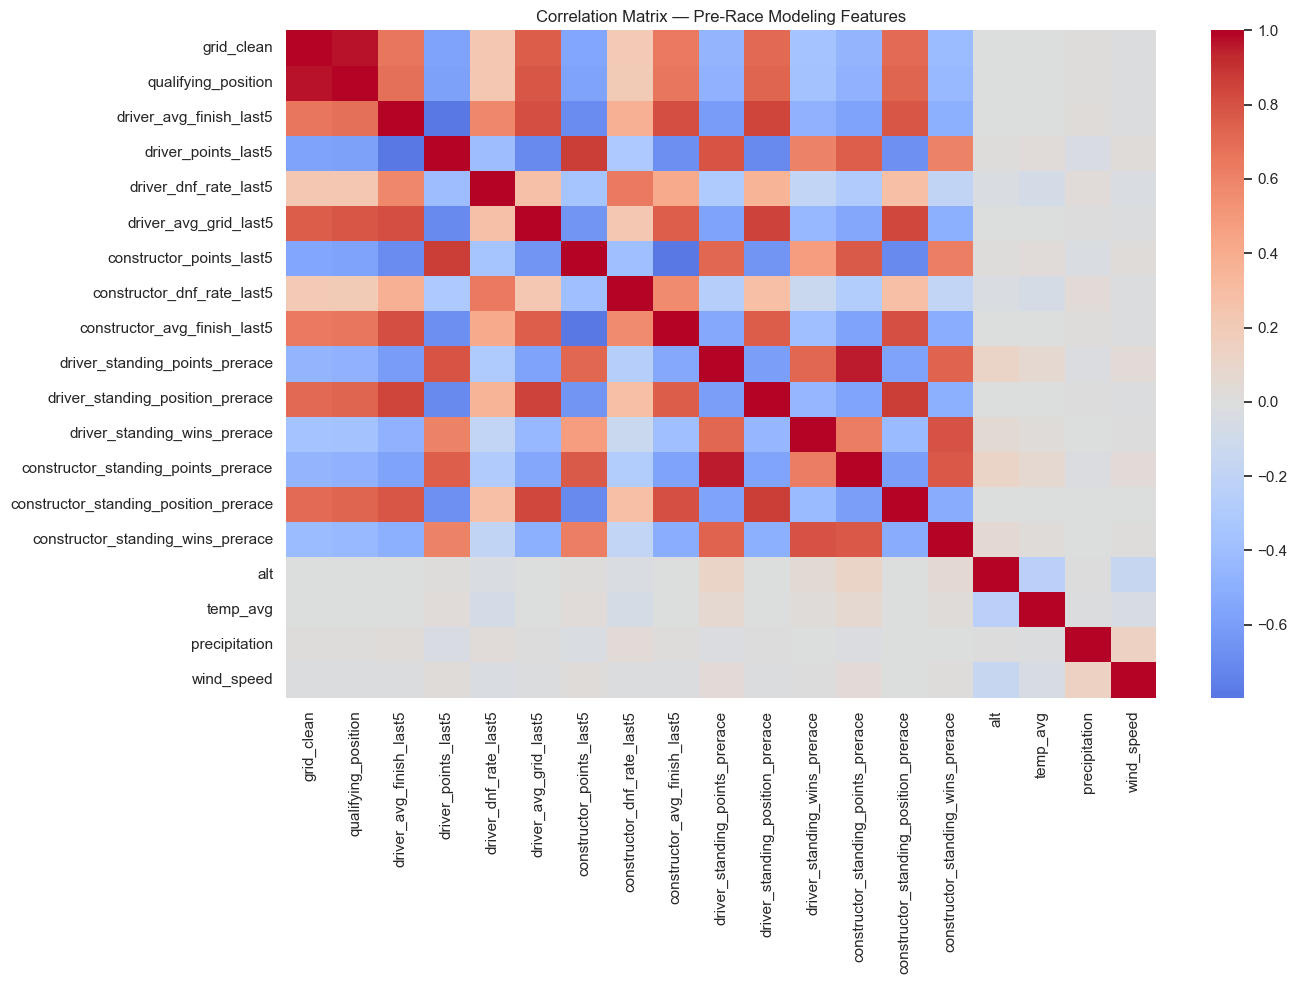

In [38]:
FIG_DIR = "outputs/figures_05"
os.makedirs(FIG_DIR, exist_ok=True)

PRERACE_MODEL_VARS = [
    "grid_clean",
    "qualifying_position",
    "driver_avg_finish_last5",
    "driver_points_last5",
    "driver_dnf_rate_last5",
    "driver_avg_grid_last5",
    "constructor_points_last5",
    "constructor_dnf_rate_last5",
    "constructor_avg_finish_last5",
    "driver_standing_points_prerace",
    "driver_standing_position_prerace",
    "driver_standing_wins_prerace",
    "constructor_standing_points_prerace",
    "constructor_standing_position_prerace",
    "constructor_standing_wins_prerace",
    "alt",
    "temp_avg",
    "precipitation",
    "wind_speed"
]

corr_df = (
    df_prerace[PRERACE_MODEL_VARS]
    .apply(pd.to_numeric, errors="coerce")
    .dropna()
    .copy()
)

corr = corr_df.corr()

plt.figure(figsize=(14, 10))
sns.heatmap(corr, cmap="coolwarm", center=0, annot=False)
plt.title("Correlation Matrix — Pre-Race Modeling Features")
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "17_corr_plot_pre_race.png"), dpi=300, bbox_inches="tight")
plt.show()

*A full correlation heatmap of all pre-race features, highlighting linear relationships between driver performance, constructor performance, qualifying, and environmental variables.*

*There are extremely strong correlations across multiple feature clusters—particularly among driver and constructor performance metrics (e.g., points, average finish, standings). Some relationships approach near-perfect correlation, indicating severe multicollinearity. In contrast, environmental variables (temperature, precipitation, wind) show weak correlations with performance metrics, suggesting they operate independently.*

*Much of the “predictive signal” in pre-race data is concentrated in a few underlying performance dimensions. Many engineered features are redundant proxies for driver and constructor strength. This reinforces that race outcomes are largely driven by persistent competitive hierarchies rather than isolated indicators.*

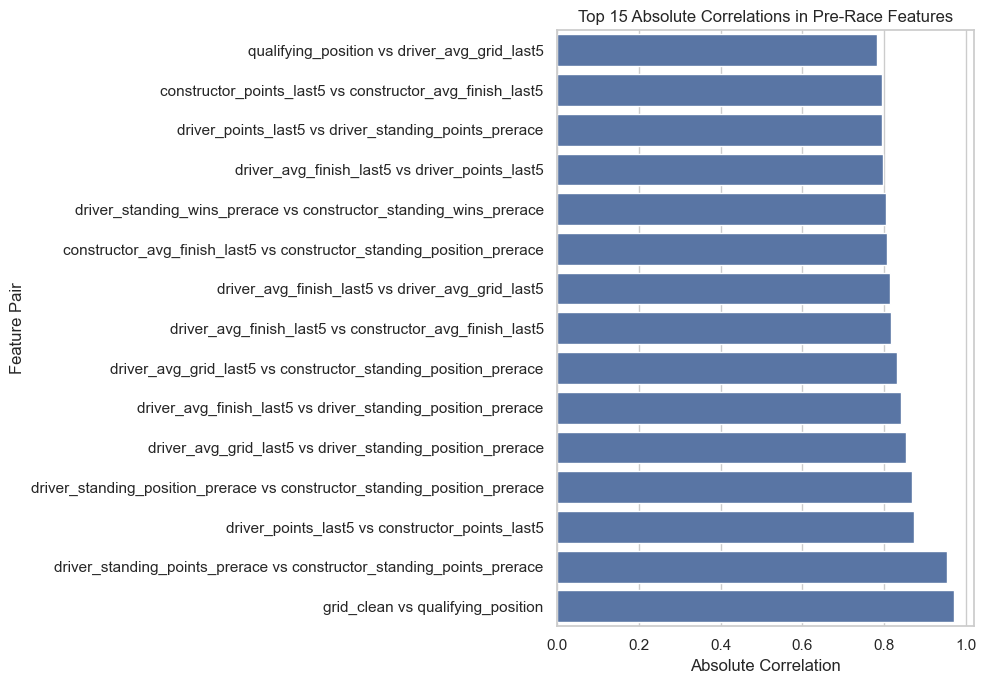

In [56]:
corr_pairs = (
    corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
    .stack()
    .reset_index()
)
corr_pairs.columns = ["feature_1", "feature_2", "correlation"]
corr_pairs["abs_corr"] = corr_pairs["correlation"].abs()

high_corr_pairs = corr_pairs.sort_values("abs_corr", ascending=False).head(15).copy()
high_corr_pairs["pair"] = high_corr_pairs["feature_1"] + " vs " + high_corr_pairs["feature_2"]

plt.figure(figsize=(10, 7))
sns.barplot(
    data=high_corr_pairs.sort_values("abs_corr", ascending=True),
    x="abs_corr",
    y="pair"
)
plt.title("Top 15 Absolute Correlations in Pre-Race Features")
plt.xlabel("Absolute Correlation")
plt.ylabel("Feature Pair")
plt.tight_layout()

FIG_DIR = "outputs/figures_05"
os.makedirs(FIG_DIR, exist_ok=True)
plt.savefig(os.path.join(FIG_DIR, "18_highly_correlated_prerace.png"), dpi=300, bbox_inches="tight")
plt.show()

*A ranked bar chart of the strongest pairwise correlations between features, focusing on the most redundant relationships in the dataset.*

*The top correlations are dominated by relationships within driver and constructor metrics (e.g., recent performance vs standings). The near-perfect correlation between grid_clean and qualifying_position confirms they are effectively duplicates. These high correlations indicate that many features contribute overlapping information, inflating variance in linear models and reducing interpretability.*

*Feature engineering without constraint can unintentionally recreate the same signal multiple times. In F1 terms, we’re repeatedly measuring the same concept—competitive strength—through slightly different lenses. Effective modeling requires collapsing these into a smaller set of meaningful factors.*

In [40]:
vif_df = pd.DataFrame()
vif_df["feature"] = corr_df.columns
vif_df["VIF"] = [
    variance_inflation_factor(corr_df.values, i)
    for i in range(corr_df.shape[1])
]

vif_df = vif_df.sort_values("VIF", ascending=False)
vif_df

,feature,VIF
2,driver_avg_finish_last5,112.063573
8,constructor_avg_finish_last5,96.292378
1,qualifying_position,78.546403
0,grid_clean,70.216175
9,driver_standing_points_prerace,40.685606
12,constructor_standing_points_prerace,40.558889
5,driver_avg_grid_last5,29.640613
13,constructor_standing_position_prerace,27.880700
10,driver_standing_position_prerace,26.159549
3,driver_points_last5,21.204123


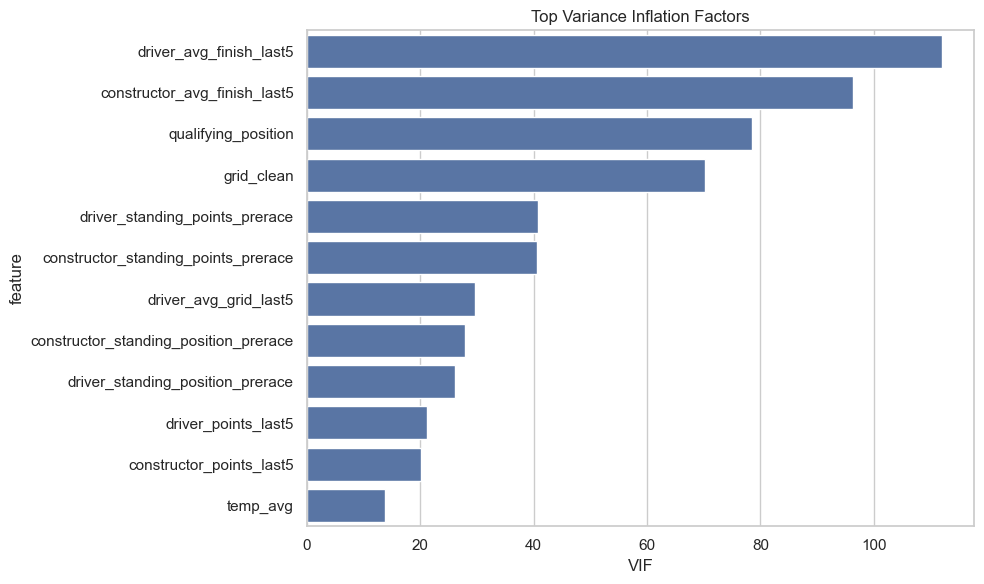

In [41]:
FIG_DIR = "outputs/figures_05"
os.makedirs(FIG_DIR, exist_ok=True)

plt.figure(figsize=(10, 6))
sns.barplot(data=vif_df.head(12), x="VIF", y="feature")
plt.title("Top Variance Inflation Factors")
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "19_VIF_prerace.png"), dpi=300, bbox_inches="tight")
plt.show()

*A bar chart of the highest VIF values across features, quantifying the degree of multicollinearity in the dataset.*

*Several features exhibit extremely high VIF values (well above standard thresholds of 5–10), confirming severe multicollinearity. This means that certain predictors can be almost perfectly explained by combinations of others, leading to unstable coefficient estimates and reduced model reliability in regression-based approaches.*

*The dataset contains overlapping definitions of performance—driver form, constructor strength, and grid position are tightly intertwined. Without reducing this redundancy, models risk “double counting” the same competitive advantage, obscuring true strategic insights.*

### Multicollinearity takeaways

The multicollinearity diagnostics confirm that the pre-race feature set contains overlapping signals rather than independent predictors. This is not just a theoretical concern: it helps explain why ordinary least squares became unstable in prior notebooks and why ridge regression performed much better once coefficient shrinkage was introduced.

## PCA (Principal Components Analysis)

In [42]:
X = corr_df.copy()

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca = PCA()
X_pca = pca.fit_transform(X_scaled)

explained_df = pd.DataFrame({
    "component": np.arange(1, len(pca.explained_variance_ratio_) + 1),
    "explained_variance_ratio": pca.explained_variance_ratio_,
    "cumulative_explained_variance": np.cumsum(pca.explained_variance_ratio_)
})

explained_df

,component,explained_variance_ratio,cumulative_explained_variance
0,1,0.479037,0.479037
1,2,0.089156,0.568193
2,3,0.079036,0.647229
3,4,0.066574,0.713802
4,5,0.059932,0.773734
5,6,0.047363,0.821098
6,7,0.036272,0.857370
7,8,0.031515,0.888885
8,9,0.028065,0.916950
9,10,0.024750,0.941700


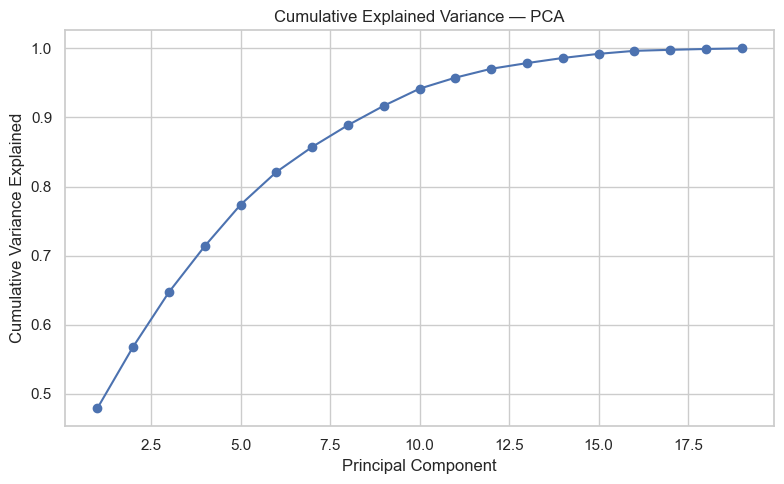

In [43]:
FIG_DIR = "outputs/figures_05"
os.makedirs(FIG_DIR, exist_ok=True)

plt.figure(figsize=(8, 5))
plt.plot(
    explained_df["component"],
    explained_df["cumulative_explained_variance"],
    marker="o"
)
plt.title("Cumulative Explained Variance — PCA")
plt.xlabel("Principal Component")
plt.ylabel("Cumulative Variance Explained")
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "20_Cumulative_explained_variance_pca.png"), dpi=300, bbox_inches="tight")
plt.show()

*The cumulative variance explained as principal components are added, illustrating how much of the dataset’s information can be captured in fewer dimensions.*

*Roughly 90% of the variance is explained by the first ~9–10 components, despite starting with a much larger feature set. This indicates strong underlying structure and redundancy—many variables collapse into a smaller number of latent factors.*

*Pre-race performance can be distilled into a handful of core dimensions—likely representing driver skill, constructor strength, and grid advantage. This reinforces the idea that race outcomes are governed by a few dominant forces rather than a wide array of independent variables.*

In [44]:
# Loadings
loadings = pd.DataFrame(
    pca.components_.T,
    index=X.columns,
    columns=[f"PC{i}" for i in range(1, X.shape[1] + 1)]
)

loadings.iloc[:, :4]

,PC1,PC2,PC3,PC4
grid_clean,0.254276,0.246987,-0.284303,-0.020954
qualifying_position,0.260958,0.239554,-0.289114,-0.017816
driver_avg_finish_last5,0.294503,0.167135,0.065095,-0.027781
driver_points_last5,-0.291491,0.112162,-0.060365,-0.029248
driver_dnf_rate_last5,0.150880,0.186491,0.572862,-0.049099
driver_avg_grid_last5,0.284736,0.181580,-0.200405,-0.012164
constructor_points_last5,-0.284799,0.072451,-0.084793,-0.022735
constructor_dnf_rate_last5,0.139030,0.195298,0.602412,-0.070872
constructor_avg_finish_last5,0.284838,0.190292,0.101779,-0.036746
driver_standing_points_prerace,-0.268603,0.365554,-0.052648,-0.032875


In [45]:
#top contributors
for pc in ["PC1", "PC2", "PC3"]:
    print(f"\nTop contributors to {pc}")
    display(
        loadings[pc]
        .sort_values(key=np.abs, ascending=False)
        .head(8)
        .to_frame("loading")
    )


Top contributors to PC1


,loading
driver_avg_finish_last5,0.294503
driver_points_last5,-0.291491
driver_standing_position_prerace,0.287808
constructor_standing_position_prerace,0.286046
constructor_avg_finish_last5,0.284838
constructor_points_last5,-0.284799
driver_avg_grid_last5,0.284736
driver_standing_points_prerace,-0.268603



Top contributors to PC2


,loading
driver_standing_wins_prerace,0.425992
constructor_standing_wins_prerace,0.407273
driver_standing_points_prerace,0.365554
constructor_standing_points_prerace,0.350340
grid_clean,0.246987
qualifying_position,0.239554
constructor_dnf_rate_last5,0.195298
constructor_avg_finish_last5,0.190292



Top contributors to PC3


,loading
constructor_dnf_rate_last5,0.602412
driver_dnf_rate_last5,0.572862
qualifying_position,-0.289114
grid_clean,-0.284303
driver_avg_grid_last5,-0.200405
temp_avg,-0.166855
constructor_standing_position_prerace,-0.142722
driver_standing_position_prerace,-0.123103


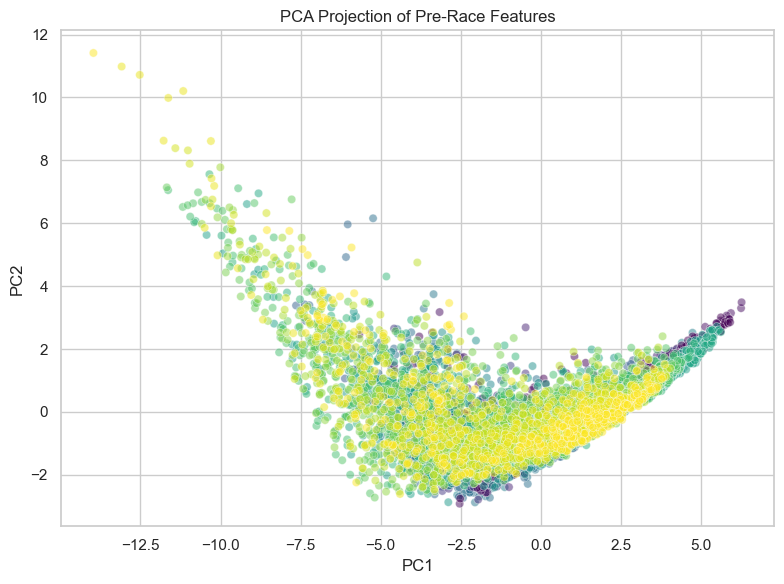

In [46]:
FIG_DIR = "outputs/figures_05"
os.makedirs(FIG_DIR, exist_ok=True)

#component plot 2D
pca_scores = pd.DataFrame(X_pca[:, :2], columns=["PC1", "PC2"])
pca_scores["year"] = df_prerace.loc[corr_df.index, "year"].values

plt.figure(figsize=(8, 6))
sns.scatterplot(data=pca_scores, x="PC1", y="PC2", hue="year", alpha=0.5, palette="viridis", legend=False)
plt.title("PCA Projection of Pre-Race Features")
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "21_projection_pre_race_features_pca.png"), dpi=300, bbox_inches="tight")
plt.show()

*A 2D projection of all observations onto the first two principal components, revealing the structure of the feature space.*

*The data forms a curved, funnel-like structure rather than distinct clusters, indicating nonlinear relationships between features. Observations are distributed along a continuum rather than separating cleanly, suggesting that performance exists on a spectrum rather than in discrete groups.*

*F1 performance is not binary (fast vs slow) but continuous and multidimensional. Drivers and teams occupy positions along a performance frontier, shaped by interacting factors rather than isolated attributes.*

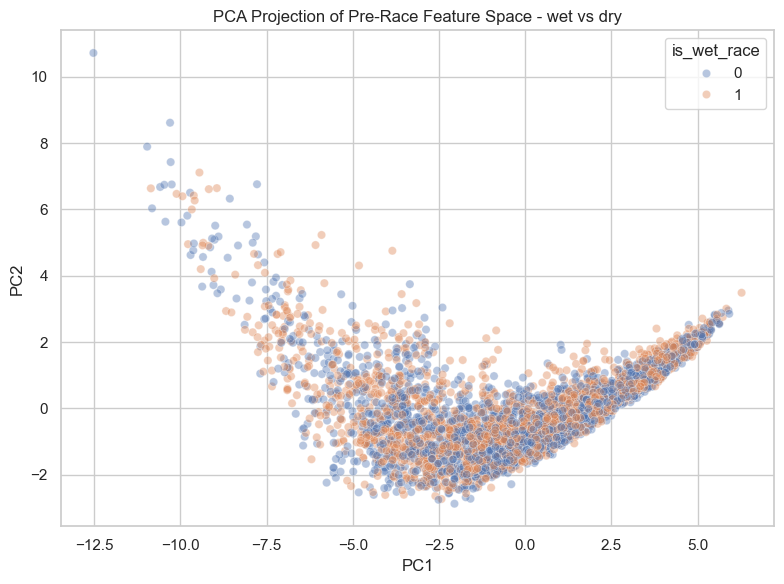

In [47]:
FIG_DIR = "outputs/figures_05"
os.makedirs(FIG_DIR, exist_ok=True)

pca_scores = pd.DataFrame(X_pca[:, :2], columns=["PC1", "PC2"])
pca_scores["year"] = df_prerace.loc[corr_df.index, "year"].values
pca_scores["is_wet_race"] = df_prerace.loc[corr_df.index, "is_wet_race"].values

plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=pca_scores.sample(min(len(pca_scores), 5000), random_state=42),
    x="PC1",
    y="PC2",
    hue="is_wet_race",
    alpha=0.4
)
plt.title("PCA Projection of Pre-Race Feature Space - wet vs dry")
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "22_wet_vs_dry_pre_race_features_pca.png"), dpi=300, bbox_inches="tight")
plt.show()

*The same PCA projection, colored by whether the race was wet or dry.*

*There is no clear separation between wet and dry races in the principal component space. This suggests that weather conditions do not fundamentally alter the underlying structure of pre-race features, at least as currently defined.*

*While wet races feel chaotic, the core competitive hierarchy remains largely intact. Weather introduces variability, but it does not fully reshuffle the underlying order—top teams and drivers still tend to occupy similar positions in the performance landscape.*

### PCA interpretation

The PCA projection helps visualize how much of the pre-race feature space compresses into a smaller number of latent dimensions. Broadly, the first few components appear to separate general driver/constructor strength from contextual variables like weather and track environment.

## Circuit Feature Reduction with PCA

In [48]:
# Circuit feature reduction with PCA
circuit_df = (
    master[["circuitId", "lat", "lng", "alt", "abs_lat", "temp_avg", "precipitation", "wind_speed"]]
    .drop_duplicates()
    .dropna()
    .copy()
)

circuit_features = ["lat", "lng", "alt", "abs_lat", "temp_avg", "precipitation", "wind_speed"]

X_circuit = circuit_df[circuit_features]
X_circuit_scaled = StandardScaler().fit_transform(X_circuit)

pca_circuit = PCA()
X_circuit_pca = pca_circuit.fit_transform(X_circuit_scaled)

circuit_explained = pd.DataFrame({
    "component": np.arange(1, len(pca_circuit.explained_variance_ratio_) + 1),
    "explained_variance_ratio": pca_circuit.explained_variance_ratio_,
    "cumulative_explained_variance": np.cumsum(pca_circuit.explained_variance_ratio_)
})

circuit_explained

,component,explained_variance_ratio,cumulative_explained_variance
0,1,0.302443,0.302443
1,2,0.204085,0.506528
2,3,0.160601,0.667128
3,4,0.132342,0.799470
4,5,0.104320,0.903791
5,6,0.056087,0.959878
6,7,0.040122,1.000000


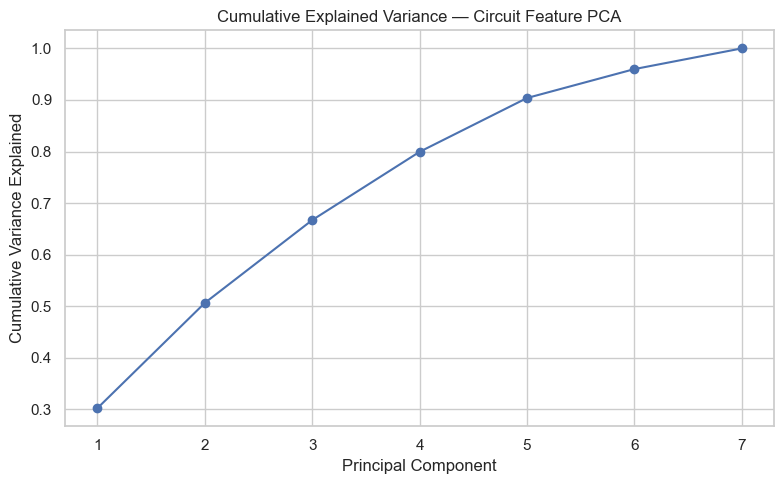

In [49]:
FIG_DIR = "outputs/figures_05"
os.makedirs(FIG_DIR, exist_ok=True)

plt.figure(figsize=(8, 5))
plt.plot(
    circuit_explained["component"],
    circuit_explained["cumulative_explained_variance"],
    marker="o"
)
plt.title("Cumulative Explained Variance — Circuit Feature PCA")
plt.xlabel("Principal Component")
plt.ylabel("Cumulative Variance Explained")
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "23_cumulative_explained_variance_circuit_features_pca.png"), dpi=300, bbox_inches="tight")
plt.show()

*The cumulative variance explained by principal components derived from circuit-specific features.*

*Approximately 90% of variance is captured within the first 5–6 components, indicating that track characteristics are also highly compressible and structured.*

*Circuits can be described through a limited number of underlying dimensions—such as speed profile, technical complexity, or environmental exposure. This suggests that track differences are systematic and can be efficiently incorporated into modeling.*

In [50]:
circuit_loadings = pd.DataFrame(
    pca_circuit.components_.T,
    index=circuit_features,
    columns=[f"PC{i}" for i in range(1, len(circuit_features) + 1)]
)

circuit_loadings.iloc[:, :3]

,PC1,PC2,PC3
lat,0.584218,-0.080891,-0.139095
lng,-0.205915,-0.596043,-0.068963
alt,-0.163349,0.715131,0.132304
abs_lat,0.621042,-0.093019,-0.019079
temp_avg,-0.441349,-0.190855,-0.397842
precipitation,-0.092048,-0.086081,0.643403
wind_speed,-0.025504,-0.272560,0.621114


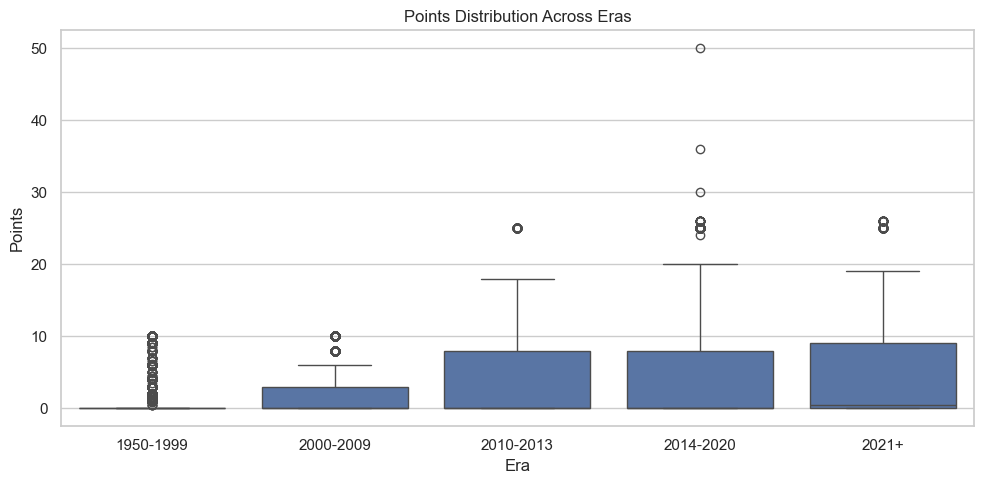

In [51]:
FIG_DIR = "outputs/figures_05"
os.makedirs(FIG_DIR, exist_ok=True)

df_outcomes["era"] = pd.cut(
    df_outcomes["year"],
    bins=[1949, 1999, 2009, 2013, 2020, 2030],
    labels=["1950-1999", "2000-2009", "2010-2013", "2014-2020", "2021+"]
)

plt.figure(figsize=(10, 5))
sns.boxplot(data=df_outcomes, x="era", y="points")
plt.title("Points Distribution Across Eras")
plt.xlabel("Era")
plt.ylabel("Points")
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "24_points_distro_eras.png"), dpi=300, bbox_inches="tight")
plt.show()


*Later eras exhibit higher medians, greater spread, and more extreme outliers. This reflects structural changes in scoring systems and competitive dynamics over time. Earlier eras show compressed distributions with fewer high-point outcomes.*

*Points are not directly comparable across eras without adjustment. Changes in scoring rules and race structure have fundamentally altered the scale and variability of outcomes, meaning historical normalization is essential for fair comparisons.*

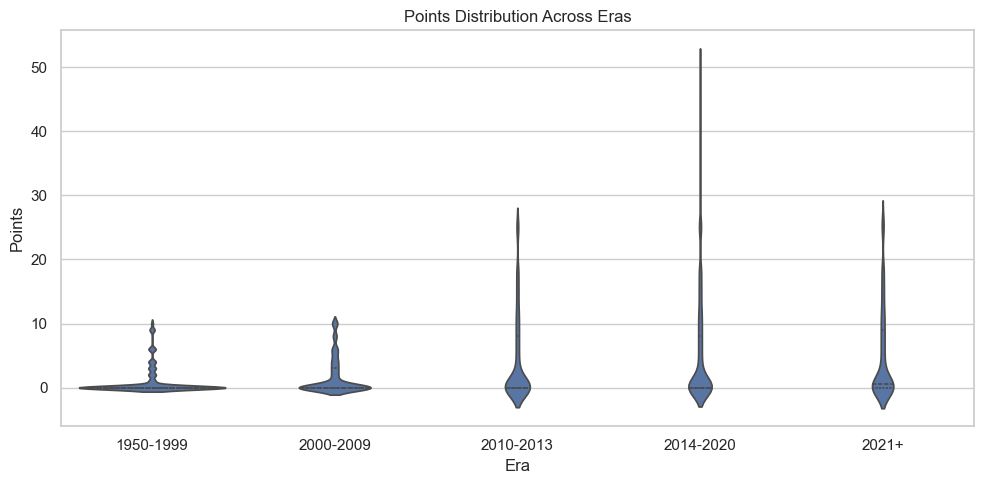

In [52]:
FIG_DIR = "outputs/figures_05"
os.makedirs(FIG_DIR, exist_ok=True)

plt.figure(figsize=(10, 5))
sns.violinplot(data=df_outcomes, x="era", y="points", inner="quartile")
plt.title("Points Distribution Across Eras")
plt.xlabel("Era")
plt.ylabel("Points")
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "25_points_by_era_violin_chart.png"), dpi=300, bbox_inches="tight")
plt.show()

*A violin plot illustrating the full distribution shape of points across eras, including density and tail behavior.*

*Modern eras display heavier tails and wider distributions, indicating a higher likelihood of extreme outcomes. The density spreads also reveal more variability in scoring, consistent with increased competitiveness and expanded point systems.*

*The modern F1 era is characterized by greater volatility and opportunity for high scoring. This reinforces the importance of contextualizing performance within its era—what counts as an “exceptional” result has evolved significantly over time.*

## Statistical Implications for the Project

This notebook helps explain several modeling results from earlier analyses:

- Many F1 variables are strongly non-normal, especially pit stop and lap-time measures.
- Strategy-related variables are more heavy-tailed than outcome variables, reflecting rare but high-impact race events.
- Transformations such as Yeo-Johnson and Box-Cox materially improve distribution shape for skewed inputs.
- Multicollinearity is structural in the pre-race feature store, which helps explain why ridge regression outperformed ordinary least squares.
- PCA shows that both pre-race and circuit-level features compress into a smaller set of latent dimensions, supporting more compact representations of race context.

## Key Takeaways

- Outcome variables are more bounded and structured than tactical variables.
- Strategy and pit variables exhibit strong skewness and heavy tails, reflecting rare but high-impact race events.
- Transformations such as log, Box-Cox, and Yeo-Johnson materially improve distributional shape for pit-stop and lap-time variables.
- Correlation and VIF diagnostics confirm meaningful multicollinearity in pre-race features, which helps explain why ridge regression outperformed ordinary least squares in earlier modeling.
- PCA suggests that pre-race and circuit-level features compress into a smaller number of latent dimensions, supporting more compact representations of race context.